In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
import glob 
import pandas as pd
import scipy
from mpl_toolkits.basemap import Basemap
import datetime
from matplotlib.dates import MonthLocator, DateFormatter
import datetime as dt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import AutoMinorLocator, MultipleLocator, FuncFormatter
from matplotlib.dates import YearLocator
from scipy.stats import pearsonr as p
plt.rcParams['font.weight']='bold'
import xskillscore as xs
plt.style.use('default')

In [2]:
error=xr.open_dataset('TA_final_input_uncertainty.nc').TA
ta=xr.open_dataset('TA_final_ensemble.nc').TA
# error=error.where(~((error.Lon>=50)&(error.Lat<=28)&(error.Lon<=55)&(error.Lat>=20)))

In [3]:
!pwd


/home/incois/prasanna/ML_XGboost/CMEMS_0.25deg


In [4]:
input_err=xr.open_dataset('Monte_Carlo_latest.nc').TU1
input_err

<xarray.DataArray 'TU1' (Time: 336, Lat: 313, Lon: 600)> Size: 252MB
[63100800 values with dtype=float32]
Coordinates:
  * Time     (Time) datetime64[ns] 3kB 1993-01-16T12:00:00 ... 2020-12-16T12:...
  * Lat      (Lat) float32 1kB 0.0 0.08333 0.1667 0.25 ... 25.83 25.92 26.0
  * Lon      (Lon) float32 2kB 50.0 50.08 50.17 50.25 ... 99.75 99.83 99.92

# Uncertainty

# Final_Uncertainty_Plot

# %Calculations

# SODA

# Representation Uncertainty New Version (saved already.. Use the file...)

# Plots

In [5]:
Represent_uncer = xr.open_dataset('Representation_uncer.nc').RU

In [6]:
annual=0
for i in range(len(error.Time)):
    annual=annual+((1.4*error[i,:,:]))**2
    
kk=np.sqrt(annual/len(error.Time)) 


annual1=0
for i in range(len(input_err.Time)):
    annual1=annual1+(1.3*input_err[i,:,:])**2
    
kk1=np.sqrt(annual1/len(error.Time))

In [7]:
# kk1.sel(Lon=slice(60,65),Lat=slice(0,30)).mean()

In [8]:
R_coarse=Represent_uncer

In [9]:
annual2=0
for i in range(len(R_coarse.Time[1:-2])):
    # print(i)
    annual2=annual2+(1*R_coarse[i+1,:,:])**2
    # print(annual2.min())
    
kk4=np.sqrt(annual2/len(R_coarse.Time[1:-2])) 

In [10]:
kk4.sel(Lon=slice(78,100),Lat=slice(0,24)).mean()

<xarray.DataArray 'RU' ()> Size: 8B
array(8.53085315)
Coordinates:
    Time     datetime64[ns] 8B 2020-10-16T12:00:00

In [11]:
error1=np.sqrt((1.4*error)**2+5**2+2**2+(1.3*input_err**2)+R_coarse**2)
error1.name='Uncertainty'
# error1.to_netcdf('Full_error_TA_5.nc')

<xarray.DataArray ()> Size: 8B
array(53.36573845)
Coordinates:
    Time     datetime64[ns] 8B 2020-10-16T12:00:00 <xarray.DataArray ()> Size: 8B
array(18.54691641)
Coordinates:
    Time     datetime64[ns] 8B 2020-10-16T12:00:00


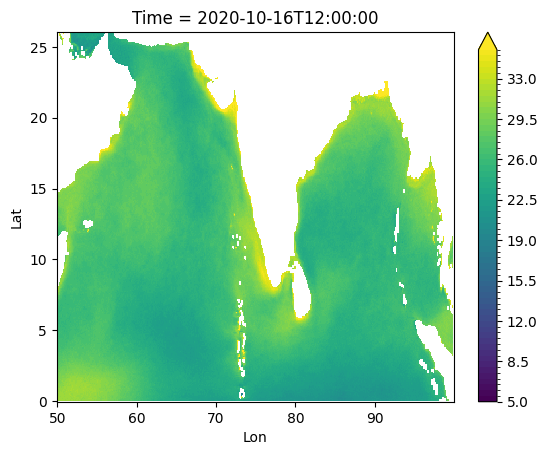

In [12]:
TU=np.sqrt((kk)**2+kk1**2+5**2+kk4**2+2**2)
print(TU.max(),TU.min())
TU.plot(robust=True,levels=np.arange(5,36,.5))

In [13]:
import matplotlib.pyplot as plt
import numpy as np

In [205]:
# TU_check = np.sqrt(kk**2+5**2+kk4**2+2**2+kk1**2)

In [206]:
# TU_check.plot(robust=True)

# End

# NEW_Updated_Fig (color-blind friendly)  \(To do these plots use pyart_env where pyart is installed properly)[Fig10 and uncertainty] 

In [14]:
import matplotlib.pyplot as plt
import numpy as np

import pyart
import matplotlib
import cmweather
import xarray as xr
import numpy as np
from colorspacious import cspace_convert


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



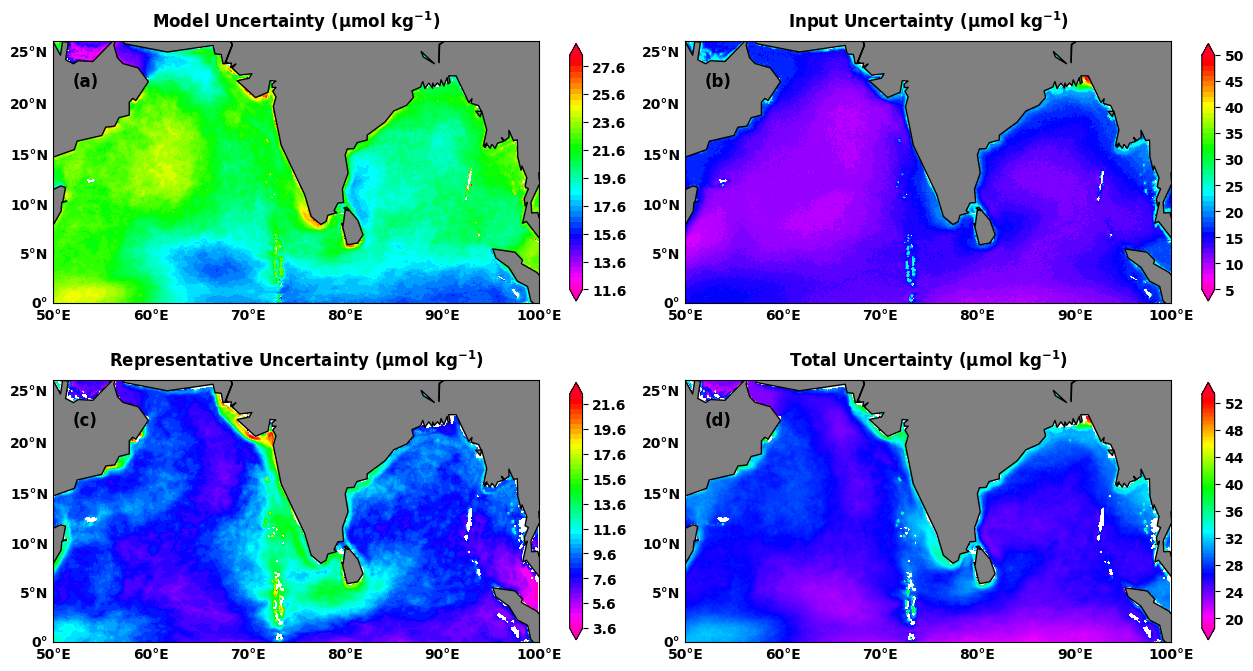

In [18]:
import matplotlib.pyplot as plt
import numpy as np

import pyart
import matplotlib
import cmweather
import xarray as xr
import numpy as np
from colorspacious import cspace_convert

fig,ax=plt.subplots(2,2,figsize=(16,22))
from mpl_toolkits.basemap import Basemap
fig.subplots_adjust(hspace=-.75,wspace=0.04)
map = Basemap(projection='merc', llcrnrlat=0, urcrnrlat=26,
llcrnrlon=50, urcrnrlon=100, resolution='c')
plt.rcParams['font.weight']='bold'


ax=ax.ravel()

# fig.delaxes(ax[3])

xx,yy=np.meshgrid(kk.Lon,kk.Lat)
xxx,yyy=map(xx,yy)

for i in range(4):
    if i in [0]:
        p=ax[i].contourf(xxx,yyy,kk,55,cmap='gist_rainbow_r',extend='both')  #levels=np.arange(10.6,25.3,.1)
        #         p=ax[i].pcolormesh(xxx,yyy,annual_un,cmap='jet',norm=norm_pc,vmax=35.97)
        cb=plt.colorbar(p,ax=ax[i],shrink=0.19) #,ticks=list1                     #,ticks=np.arange(10.6,25.3,1.3)
#         cb.set_label('(\u00B5atm)',fontweight='bold')

    elif i in [1]:
        p=ax[i].contourf(xxx,yyy,kk1,55,cmap='gist_rainbow_r',extend='both')
        #         p=ax[i].pcolormesh(xxx,yyy,repre_un,cmap='jet',norm=norm_pc1)
        cb=plt.colorbar(p,ax=ax[i],shrink=0.19)
#         cb.set_label('(\u00B5atm)',fontweight='bold')
    
    elif i in [3]:
        p=ax[i].contourf(xxx,yyy,TU,55,levels=np.arange(TU.min(),TU.max(),.2),cmap='gist_rainbow_r',extend='both')
        #         p=ax[i].pcolormesh(xxx,yyy,total_unc,cmap='jet',norm=norm_pc11)
        cb=plt.colorbar(p,ax=ax[i],ticks=np.arange(20,53,4),shrink=0.19)  #,ticks=np.arange(20,44,4)
#         cb.set_label('(\u00B5atm)',fontweight='bold')

    elif i in [2]:
        p=ax[i].contourf(xxx,yyy,kk4,55,cmap='gist_rainbow_r',extend='both')  #pyart_ChaseSpectral
        #         p=ax[i].pcolormesh(xxx,yyy,total_unc,cmap='jet',norm=norm_pc11)
        cb=plt.colorbar(p,ax=ax[i],shrink=0.19)
#         cb.set_label('(\u00B5atm)',fontweight='bold')

    map.drawcoastlines(linewidth=1, ax=ax[i])
    map.fillcontinents(color='grey',lake_color='aqua', ax=ax[i])
    ax[i].tick_params(axis='both', labelsize=8)
    # map.drawmeridians(np.arange(30, 120,10), color='black', ax=ax[i])
    # map.drawparallels(np.arange(-30, 30, 5), color='black', ax=ax[i])     

    if i in [0,1,2,3]:
        map.drawmeridians(np.arange(30, 120, 10), labels=[0,0,0,1], color='black', fontsize=10, ax=ax[i],zorder=0)
    if i in [0,1,2,3]:
        map.drawparallels(np.arange(-30, 30, 5), labels=[1,0,0,0], color='black', fontsize=10, ax=ax[i],zorder=0) 

ax[0].set_title('Model Uncertainty (\u03BCmol kg$^{-1}$)',fontweight='bold',fontsize=12,pad=10)
ax[1].set_title('Input Uncertainty (\u03BCmol kg$^{-1}$)',fontweight='bold',fontsize=12,pad=10)
ax[2].set_title('Representative Uncertainty (\u03BCmol kg$^{-1}$)',fontweight='bold',fontsize=12,pad=10)  #(\u221A(MU\u00B2+RU\u00B2+MeU\u00B2+PU\u00B2)
ax[3].set_title('Total Uncertainty (\u03BCmol kg$^{-1}$)',fontweight='bold',fontsize=12,pad=10)
# ax[1].set_title('Representation Error (spatil+temporal)',fontweight='bold',fontsize=12,pad=10)

for i, ax in enumerate(ax.flat):
        label = f"({chr(ord('a') + i)})"
        ax.text(0.04, 0.88, label, transform=ax.transAxes, fontsize=12, fontweight="bold", va="top") 
        
# plt.savefig("Spatial_uncer_total_TA_V3_gist_rainbow.png", dpi=400, facecolor='w', edgecolor='w',
#             orientation='potrait', bbox_inches='tight')

In [19]:
import os
os.getcwd()

'/home/incois/prasanna/ML_XGboost/CMEMS_0.25deg'

# Fig 10 (color-blind friendly) 

In [7]:
aa = xr.open_dataset("TA_final_ensemble.nc").TA
bb = xr.open_dataset("/home/prasanna/ML_XGboost/CMEMS_0.25deg/CMEMS_TA_IO_1993_2020.nc").talk
cc = xr.open_dataset("/home/prasanna/ML_XGboost/CMEMS_0.25deg/soda_TA_IO_1993_2020.nc").talk

FileNotFoundError: [Errno 2] No such file or directory: b'/home/prasanna/ML_XGboost/CMEMS_0.25deg/CMEMS_TA_IO_1993_2020.nc'

In [24]:
aa_bob = aa.sel(Lon=slice(76,100),Lat=slice(0,26))
bb_bob = bb.sel(longitude=slice(76,100),latitude=slice(0,26))
cc_bob = cc.sel(lon=slice(76,100),lat=slice(0,26))


aa_djf = aa.isel(Time=[11,0,1]).mean(dim='Time')
aa_on = aa.isel(Time=[9,10]).mean(dim='Time')
aa_MAM = aa.isel(Time=[2,3,4]).mean(dim='Time')
aa_JJAS = aa.isel(Time=[5,6,7,8]).mean(dim='Time')

aa_list = [aa_djf,aa_MAM,aa_JJAS,aa_on]

bb_djf = bb.isel(month=[11,0,1]).mean(dim='month')
bb_on = bb.isel(month=[9,10]).mean(dim='month')
bb_MAM = bb.isel(month=[2,3,4]).mean(dim='month')
bb_JJAS = bb.isel(month=[5,6,7,8]).mean(dim='month')

bb_list = [bb_djf,bb_MAM,bb_JJAS,bb_on]

cc_djf = cc.isel(month=[11,0,1]).mean(dim='month')
cc_on = cc.isel(month=[9,10]).mean(dim='month')
cc_MAM = cc.isel(month=[2,3,4]).mean(dim='month')
cc_JJAS = cc.isel(month=[5,6,7,8]).mean(dim='month')


cc_list = [cc_djf,cc_MAM,cc_JJAS,cc_on]






In [1]:
plt.rcParams['font.weight']='bold'
month_labels = ['DJF','MAM','JJAS','ON']
fig, axn = plt.subplots(4, 1, figsize=(18,12),sharex=True, sharey=True)
fig.subplots_adjust( hspace=0.12, wspace=0)
map = Basemap(projection='merc', llcrnrlat=0, urcrnrlat=26,
            llcrnrlon=50, urcrnrlon=100, resolution='c')
lon1, lat1 = np.meshgrid(aa.Lon,aa.Lat) 
lon2, lat2 = map(lon1, lat1)
for i, ax in enumerate(axn.ravel()):
# for i in range(12):
#         p= map.ccolormesh(lon2,lat2,cc[i,:,:], cmap='gist_rainbow_r', shading = 'gouraud', edgecolors ='face',ax=ax,norm=norm)
        p=map.contourf(lon2,lat2,aa_list[i], 55,cmap='ChaseSpectral',ax=ax,levels=np.arange(2000,2450,5),extend='both')
        
        if i in [0]:
            ax.set_title('INCOIS_TA',fontsize=16,fontweight='bold')
        ax.text(0.01,0.8,month_labels[i],transform=ax.transAxes,fontsize=14,fontweight='bold')
        map.drawcoastlines(linewidth=1, ax=ax)
        map.fillcontinents(color='grey',lake_color='aqua', ax=ax)
        ax.tick_params(axis='both', labelsize=8)
        map.drawmeridians(np.arange(52, 102,8), color='black', fontsize=8, ax=ax, zorder=10)
        map.drawparallels(np.arange(0, 26, 5), color='black', fontsize=8, ax=ax, zorder=10)
        if i in [3]:
            map.drawmeridians(np.arange(52, 102, 8), labels=[0,0,0,1], color='black', fontsize=12, ax=ax)
        if i in [0, 1, 2, 3]:
            map.drawparallels(np.arange(0, 26, 5), labels=[1,0,0,0], color='black', fontsize=12, ax=ax)
        
# cbar = fig.colorbar(p, ax=axn[:], extend='max', extendfrac=.05, extendrect=False, fraction = 0.05,shrink=0.8,aspect=40,pad=0.025)
# cbar.minorticks_off()
# plt.savefig("INCOIS_TA_seasonal.png", dpi=300, facecolor='w', edgecolor='w',
#  orientation='potrait', bbox_inches='tight')

NameError: name 'plt' is not defined

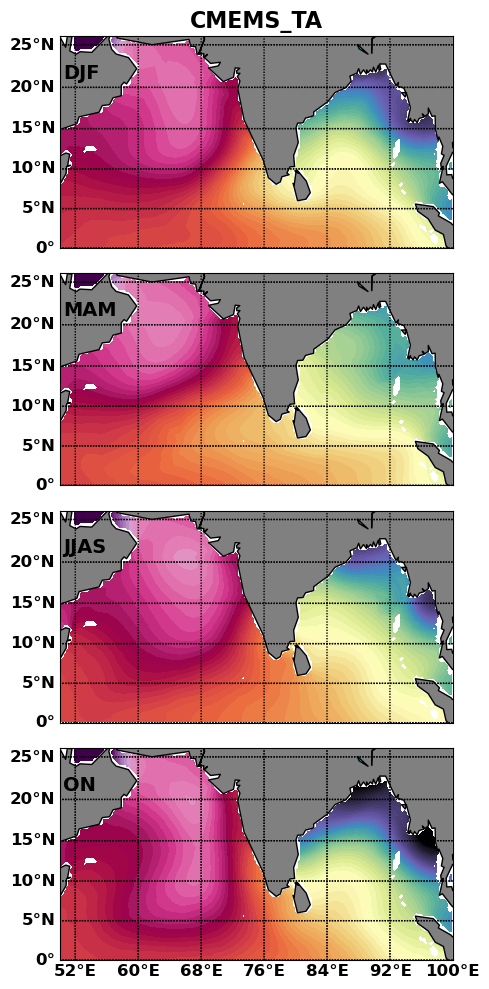

In [65]:
plt.rcParams['font.weight']='bold'
month_labels = ['DJF','MAM','JJAS','ON']
fig, axn = plt.subplots(4, 1, figsize=(18,12),sharex=True, sharey=True)
fig.subplots_adjust( hspace=0.12, wspace=0)
map = Basemap(projection='merc', llcrnrlat=0, urcrnrlat=26,
            llcrnrlon=50, urcrnrlon=100, resolution='c')
lon1, lat1 = np.meshgrid(bb.longitude,bb.latitude) 
lon2, lat2 = map(lon1, lat1)
for i, ax in enumerate(axn.ravel()):
# for i in range(12):
#         p= map.ccolormesh(lon2,lat2,cc[i,:,:], cmap='gist_rainbow_r', shading = 'gouraud', edgecolors ='face',ax=ax,norm=norm)
        p=map.contourf(lon2,lat2,bb_list[i], 55,cmap='pyart_ChaseSpectral',ax=ax,levels=np.arange(2000,2450,5),extend='both')
        
        if i in [0]:
            ax.set_title('CMEMS_TA',fontsize=16,fontweight='bold')
        ax.text(0.01,0.8,month_labels[i],transform=ax.transAxes,fontsize=14,fontweight='bold')
        map.drawcoastlines(linewidth=1, ax=ax)
        map.fillcontinents(color='grey',lake_color='aqua', ax=ax)
        ax.tick_params(axis='both', labelsize=8)
        map.drawmeridians(np.arange(52, 102,8), color='black', fontsize=8, ax=ax, zorder=10)
        map.drawparallels(np.arange(0, 26, 5), color='black', fontsize=8, ax=ax, zorder=10)
        if i in [3]:
            map.drawmeridians(np.arange(52, 102, 8), labels=[0,0,0,1], color='black', fontsize=12, ax=ax)
        if i in [0, 1, 2, 3]:
            map.drawparallels(np.arange(0, 26, 5), labels=[1,0,0,0], color='black', fontsize=12, ax=ax)
        
# cbar = fig.colorbar(p, ax=axn[:], extend='max', extendfrac=.05, extendrect=False, fraction = 0.05,shrink=0.8,aspect=40,pad=0.025)
# cbar.minorticks_off()
# plt.savefig("CMEMS_TA_seasonal.png", dpi=300, facecolor='w', edgecolor='w',
#  orientation='potrait', bbox_inches='tight')

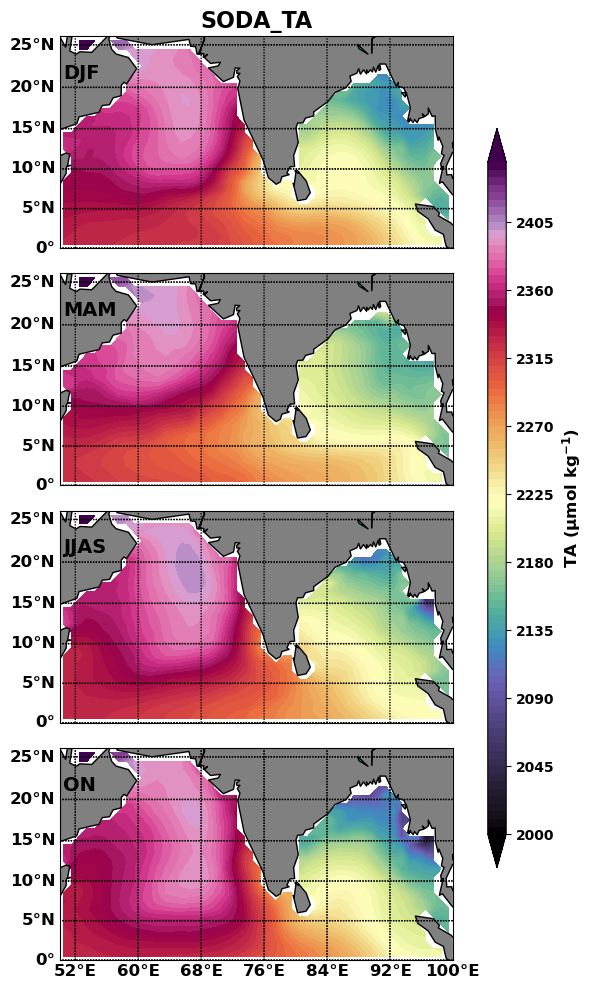

In [66]:
plt.rcParams['font.weight']='bold'
month_labels = ['DJF','MAM','JJAS','ON']
fig, axn = plt.subplots(4, 1, figsize=(18,12),sharex=True, sharey=True)
fig.subplots_adjust( hspace=0.12, wspace=0)
map = Basemap(projection='merc', llcrnrlat=0, urcrnrlat=26,
            llcrnrlon=50, urcrnrlon=100, resolution='c')
lon1, lat1 = np.meshgrid(cc.lon,cc.lat
                        ) 
lon2, lat2 = map(lon1, lat1)
for i, ax in enumerate(axn.ravel()):
# for i in range(12):
#         p= map.ccolormesh(lon2,lat2,cc[i,:,:], cmap='gist_rainbow_r', shading = 'gouraud', edgecolors ='face',ax=ax,norm=norm)
        p=map.contourf(lon2,lat2,cc_list[i], 55,cmap='pyart_ChaseSpectral',ax=ax,levels=np.arange(2000,2450,5),extend='both')
        
        if i in [0]:
            ax.set_title('SODA_TA',fontsize=16,fontweight='bold')
        ax.text(0.01,0.8,month_labels[i],transform=ax.transAxes,fontsize=14,fontweight='bold')
        map.drawcoastlines(linewidth=1, ax=ax)
        map.fillcontinents(color='grey',lake_color='aqua', ax=ax)
        ax.tick_params(axis='both', labelsize=8)
        map.drawmeridians(np.arange(52, 102,8), color='black', fontsize=8, ax=ax, zorder=10)
        map.drawparallels(np.arange(0, 26, 5), color='black', fontsize=8, ax=ax, zorder=10)
        if i in [3]:
            map.drawmeridians(np.arange(52, 102, 8), labels=[0,0,0,1], color='black', fontsize=12, ax=ax)
        if i in [0, 1, 2, 3]:
            map.drawparallels(np.arange(0, 26, 5), labels=[1,0,0,0], color='black', fontsize=12, ax=ax)
        
cbar = fig.colorbar(p, ax=axn[:], extend='max', extendfrac=.05, extendrect=False, fraction = 0.05,shrink=0.8,aspect=40,pad=0.025)
cbar.set_label('TA (\u03BCmol kg$^{-1}$)',fontsize=12,fontweight='bold')
cbar.minorticks_off()
# plt.savefig("SODA_TA_seasonal.png", dpi=300, facecolor='w', edgecolor='w',
#  orientation='potrait', bbox_inches='tight')

# trend

In [9]:
###########our data######################################
ta=xr.open_dataset('Ensembled_Inter_1993_2020_TA.nc').TA
ta_as=ta.sel(Lon=slice(50,78)).mean(dim=['Lon','Lat'])
ta_bob=ta.sel(Lon=slice(78,100)).mean(dim=['Lon','Lat'])


#########CMEMS Data######################################
chau=xr.open_dataset('CMEMS-LSCE_r025_IndianOcean_1985to2021.nc').talk.sel(time=slice('1993','2020'),latitude=slice(0,26))
chau_as=chau.sel(longitude=slice(50,78)).mean(dim=['longitude','latitude'])
chau_bob=chau.sel(longitude=slice(78,100)).mean(dim=['longitude','latitude'])


##########OceanSoda Data#################################

soda=xr.open_dataset('OceanSODA_1982_2022.nc').sel(time=slice('1993','2020'),lat=slice(0,26)).talk
soda_as=soda.sel(lon=slice(50,78)).mean(dim=['lon','lat'])
soda_bob=soda.sel(lon=slice(78,100)).mean(dim=['lon','lat'])

In [5]:
from scipy.stats import linregress
def reg_line(a):
    slope, intercept, rvalue, pvalue, stderr = linregress(np.arange(1,len(a)+1),a)
    reg=slope*np.arange(1,len(a)+1)+intercept
    return reg,slope*12,pvalue,stderr

In [6]:
month_fmt = DateFormatter('%b')
def m_fmt(x, pos=None):
    return month_fmt(x)[0]


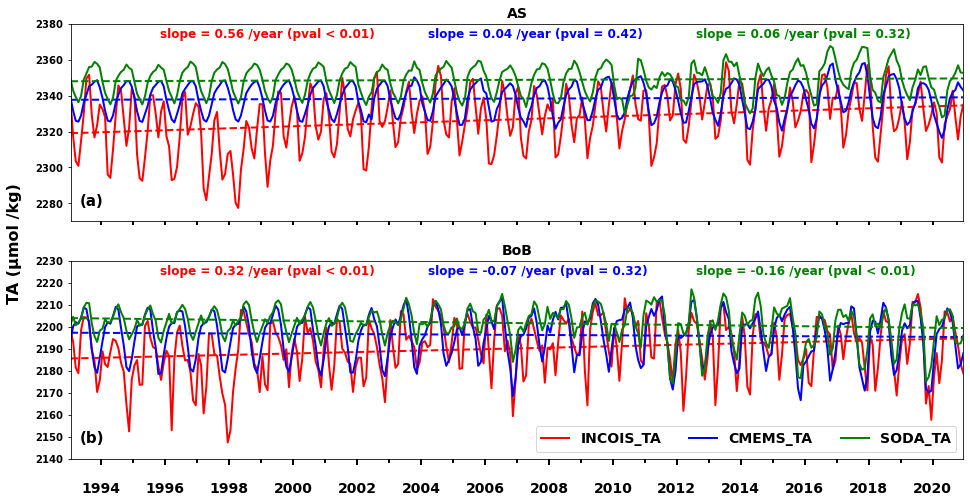

In [12]:
fig,ax=plt.subplots(2,1,figsize=(16,8))
ax=ax.ravel()
for i in range(2):
    ax[i].margins(x=0)
#     ax[i].margins(y=0)


ax[0].plot(ta_as.Time,ta_as,c='r',label='INCOIS_TA',linewidth=2)
ax[0].plot(ta_as.Time,reg_line(ta_as)[0],c='r',linewidth=2,linestyle='--')

ax[0].plot(ta_as.Time,chau_as,c='blue',label='CMEMS_TA',linewidth=2)
ax[0].plot(ta_as.Time,reg_line(chau_as)[0],c='blue',linewidth=2,linestyle='--')

ax[0].plot(ta_as.Time,soda_as,c='g',label='SODA_TA',linewidth=2)
ax[0].plot(ta_as.Time,reg_line(soda_as)[0],c='g',linewidth=2,linestyle='--')


ax[0].set_title('AS',fontsize=14,fontweight='bold')


ax[1].plot(ta_bob.Time,ta_bob,c='r',label='INCOIS_TA',linewidth=2)
ax[1].plot(ta_bob.Time,reg_line(ta_bob)[0],c='r',linewidth=2,linestyle='--')

ax[1].plot(ta_bob.Time,chau_bob,c='blue',label='CMEMS_TA',linewidth=2)
ax[1].plot(ta_bob.Time,reg_line(chau_bob)[0],c='blue',linewidth=2,linestyle='--')

ax[1].plot(ta_bob.Time,soda_bob,c='g',label='SODA_TA',linewidth=2)
ax[1].plot(ta_bob.Time,reg_line(soda_bob)[0],c='g',linewidth=2,linestyle='--')


# ax[1].set_ylabel(u'TA (\u03BCmol /kg)',fontsize=14,fontweight='bold')
ax[1].set_title('BoB',fontsize=14,fontweight='bold')

fig.supylabel(u'TA (\u03BCmol /kg)',x=0.07,fontsize=16,fontweight='bold')


for i in range(2):
        ax[i].xaxis.set_major_locator(YearLocator(2))
        ax[i].tick_params(axis='x',which='major', length=6,width=2,pad=1,labelsize=13)
        ax[i].xaxis.set_minor_locator(YearLocator(1))
        ax[i].tick_params(axis='x',which='minor',length=4, width=2,labelsize=13)
        if i in [0,1]:
#             ax[i].xaxis.set_minor_formatter(FuncFormatter(m_fmt))
            ax[i].xaxis.set_tick_params(labelsize=14)
        if i in [0]:
            ax[i].set_xticks([])
        if i in [1]:
            ax[i].xaxis.set_major_formatter(DateFormatter("\n%Y"))
            
ax[0].text(0.1, 0.98,'slope = 0.56 /year (pval < 0.01)',c='r',transform=ax[0].transAxes, fontsize=12, fontweight="bold", va="top")
ax[0].text(0.4, 0.98,'slope = 0.04 /year (pval = 0.42)',c='b',transform=ax[0].transAxes, fontsize=12, fontweight="bold", va="top")
ax[0].text(0.7, 0.98,'slope = 0.06 /year (pval = 0.32)',c='g',transform=ax[0].transAxes, fontsize=12, fontweight="bold", va="top")



ax[1].text(0.1, 0.98,'slope = 0.32 /year (pval < 0.01)',c='r',transform=ax[1].transAxes, fontsize=12, fontweight="bold", va="top")
ax[1].text(0.4, 0.98,'slope = -0.07 /year (pval = 0.32)',c='b',transform=ax[1].transAxes, fontsize=12, fontweight="bold", va="top")
ax[1].text(0.7, 0.98,'slope = -0.16 /year (pval < 0.01)',c='g',transform=ax[1].transAxes, fontsize=12, fontweight="bold", va="top")

ax[0].set_ylim([2270,2380])
ax[1].set_ylim([2140,2230])

for i, ax in enumerate(ax):
        label = f"({chr(ord('a') + i)})"
        
        ax.text(0.01, 0.14, label, transform=ax.transAxes, fontsize=15, fontweight="bold", va="top")

plt.legend(ncol=3,fontsize=14,loc='lower right')

# plt.savefig('trend_plot_interannual.png', transparent=None, dpi=400, bbox_inches='tight', facecolor='white', edgecolor='white')

In [13]:
print(reg_line(ta_as.sel(Time=slice('1993','1998')))[1:3],reg_line(ta_as.sel(Time=slice('2000','2020')))[1:3])

(-3.3417220265621985, 0.005745523534091579) (0.23757386659776764, 0.10117522105435063)


In [14]:
print(reg_line(ta_bob.sel(Time=slice('1993','1998')))[1:3],reg_line(ta_bob.sel(Time=slice('1998','2020')))[1:3])

(-1.2903140563199402, 0.16489387777057188) (0.15934248795590103, 0.14527481032378373)


# Seasonal_Comparison_SST_MLD_SSS

In [ ]:
sal_as=xr.open_dataset('/home/prasanna/GLORY3D/TA_PAPER/COP_salt_TA.nc').so.sel(longitude=slice(50,78),latitude=slice(0,26)).mean(dim=['longitude','latitude'])
fig,ax=plt.subplots(figsize=(16,4))
ax.margins(x=0)
ay=ax.twinx()
ax.plot(ta_as.Time,sal_as,c='r',label='INCOIS_TA',linewidth=2)
ay.plot(ta_as.Time,ta_as,c='b',label='INCOIS_TA',linewidth=2)

In [ ]:
np.corrcoef(sal_as.groupby('time.month').mean(),ta_as.groupby('Time.month').mean())

In [ ]:
(reg_line(sal_as)[1])

In [ ]:
p(new_ta1.sel(Lon=slice(78,100)).mean(dim=['Lon','Lat']),sal_bob)

In [ ]:
mld_as=xr.open_dataset('/home/prasanna/GLORY3D/TA_PAPER/COP_mld_TA.nc').mlotst.sel(longitude=slice(50,78),latitude=slice(0,26)).mean(dim=['longitude','latitude'])
fig,ax=plt.subplots(figsize=(16,4))
ax.margins(x=0)
ay=ax.twinx()
ax.plot(ta_as.Time,mld_as,c='r',label='INCOIS_TA',linewidth=2)
ay.plot(ta_as.Time,ta_as,c='b',label='INCOIS_TA',linewidth=2)

In [ ]:
np.corrcoef(mld_as.groupby('time.month').mean(),ta_as.groupby('Time.month').mean())

In [ ]:
chau_as.groupby('time.month').mean().plot()

In [ ]:
xr.open_dataset('/home/prasanna/GLORY3D/TA_PAPER/COP_mld_TA.nc').mlotst.sel(longitude=slice(78,100),latitude=slice(0,26)).mean(dim=['longitude','latitude']).groupby('time.month').mean().plot()

In [ ]:
temp_as=xr.open_dataset('/home/prasanna/GLORY3D/TA_PAPER/COP_sst_TA.nc').thetao.sel(longitude=slice(50,78),latitude=slice(0,26)).mean(dim=['longitude','latitude'])
fig,ax=plt.subplots(figsize=(16,4))
ax.margins(x=0)
ay=ax.twinx()
ax.plot(ta_as.Time,temp_as,c='r',label='INCOIS_TA',linewidth=2)
ay.plot(ta_as.Time,ta_as,c='b',label='INCOIS_TA',linewidth=2)

In [ ]:
np.corrcoef(temp_as.groupby('time.month').mean(),ta_as.groupby('Time.month').mean())

In [ ]:
reg_line(temp_as)[1:3]

# SST,SSS,MLD,TA lineplot

In [ ]:
time=ta_as.Time

In [ ]:
fig, axs = plt.subplots(3, 1, figsize=(16, 10))

# Plot on each subplot with twinx
for i, ax in enumerate(axs):
    ax.margins(x=0)
    ax.plot(time, ta_as, color='k',linewidth=2)
#     ax.set_ylabel(u'TA (\u03BCmol /kg)', color='r')
    ax.tick_params(axis='y', colors='k')
    ax.spines['left'].set_color('k')
    
    ax_twin = ax.twinx()
    ax_twin.margins(x=0)
    if i == 0:
        ax_twin.plot(time,temp_as, color='g',linewidth=2)
        ax_twin.set_ylabel('SST (\u00b0C)', color='g',fontweight='bold',fontsize=12)
        ax_twin.tick_params(axis='y', colors='g')
        ax_twin.spines['right'].set_color('g')
    elif i==1:
        ax_twin.plot(time,sal_as, color='r',linewidth=2)
        ax_twin.set_ylabel('SSS', color='r',fontweight='bold',fontsize=12)
        ax_twin.tick_params(axis='y', colors='r')
        ax_twin.spines['right'].set_color('r')
    elif i==2:
        ax_twin.plot(time,mld_as, color='b',linewidth=2)
        ax_twin.set_ylabel('MLD (m)', color='b',fontweight='bold',fontsize=12)
        ax_twin.tick_params(axis='y', colors='b')
        ax_twin.set_ylim([0,40])
        ax_twin.spines['right'].set_color('b')
        
fig.supylabel(u'INCOIS_TA (\u03BCmol/kg)',x=0.07,fontsize=16,fontweight='bold',c='k')

for i, ax in enumerate(axs):
        label = f"({chr(ord('a') + i)})"
        
        ax.text(0.01, 0.14, label, transform=ax.transAxes, fontsize=15, fontweight="bold", va="top")
for i, ax in enumerate(axs):
        ax.xaxis.set_major_locator(YearLocator(2))
        ax.tick_params(axis='x',which='major', length=6,width=2,pad=0,labelsize=13)
        ax.xaxis.set_minor_locator(YearLocator(1))
        ax.tick_params(axis='x',which='minor',length=4, width=2,labelsize=13)
        if i in [0,1]:
#             ax[i].xaxis.set_minor_formatter(FuncFormatter(m_fmt))
            ax.xaxis.set_tick_params(labelsize=14)
        if i in [0,1]:
            ax.set_xticks([])
        if i in [2]:
            ax.xaxis.set_major_formatter(DateFormatter("\n%Y"))  
axs[0].set_title('AS',fontsize=14,fontweight='bold')

# plt.savefig('TA_SST_SSS_MLD_interannual_AS.png', transparent=None, dpi=400, bbox_inches='tight', facecolor='white', edgecolor='white')            

In [ ]:
sal_bob=xr.open_dataset('/home/prasanna/GLORY3D/TA_PAPER/COP_salt_TA.nc').so.sel(longitude=slice(78,100),latitude=slice(0,26)).mean(dim=['longitude','latitude'])
mld_bob=xr.open_dataset('/home/prasanna/GLORY3D/TA_PAPER/COP_mld_TA.nc').mlotst.sel(longitude=slice(78,100),latitude=slice(0,26)).mean(dim=['longitude','latitude'])
temp_bob=xr.open_dataset('/home/prasanna/GLORY3D/TA_PAPER/COP_sst_TA.nc').thetao.sel(longitude=slice(78,100),latitude=slice(0,26)).mean(dim=['longitude','latitude'])


In [ ]:
print(reg_line(temp_bob)[1:3])
print(reg_line(sal_bob)[1:3])
print(reg_line(mld_bob)[1:3])

In [ ]:
fig, axs = plt.subplots(3, 1, figsize=(16, 10))

for i, ax in enumerate(axs):
    ax.margins(x=0)
    ax.plot(time, ta_bob, color='k',linewidth=2)
#     ax.set_ylabel(u'TA (\u03BCmol /kg)', color='r')
    ax.tick_params(axis='y', colors='k')
    ax.spines['left'].set_color('k')
    
    ax_twin = ax.twinx()
    ax_twin.margins(x=0)
    if i == 0:
        ax_twin.plot(time,temp_bob, color='g',linewidth=2)
        ax_twin.set_ylabel('SST (\u00b0C)', color='g',fontweight='bold',fontsize=12)
        ax_twin.tick_params(axis='y', colors='g')
        ax_twin.spines['right'].set_color('g')
    elif i==1:
        ax_twin.plot(time,sal_bob, color='r',linewidth=2)
        ax_twin.set_ylabel('SSS', color='r',fontweight='bold',fontsize=12)
        ax_twin.tick_params(axis='y', colors='r')
        ax_twin.spines['right'].set_color('r')
    elif i==2:
        ax_twin.plot(time,mld_bob, color='b',linewidth=2)
        ax_twin.set_ylabel('MLD (m)', color='b',fontweight='bold',fontsize=12)
        ax_twin.tick_params(axis='y', colors='b')
        ax_twin.set_ylim([0,40])
        ax_twin.spines['right'].set_color('b')
        
fig.supylabel(u'INCOIS_TA (\u03BCmol/kg)',x=0.07,fontsize=16,fontweight='bold',c='k')

for i, ax in enumerate(axs):
        label = f"({chr(ord('a') + i)})"
        
        ax.text(0.01, 0.14, label, transform=ax.transAxes, fontsize=15, fontweight="bold", va="top")
for i, ax in enumerate(axs):
        ax.xaxis.set_major_locator(YearLocator(2))
        ax.tick_params(axis='x',which='major', length=6,width=2,pad=0,labelsize=13)
        ax.xaxis.set_minor_locator(YearLocator(1))
        ax.tick_params(axis='x',which='minor',length=4, width=2,labelsize=13)
        if i in [0,1]:
#             ax[i].xaxis.set_minor_formatter(FuncFormatter(m_fmt))
            ax.xaxis.set_tick_params(labelsize=14)
        if i in [0,1]:
            ax.set_xticks([])
        if i in [2]:
            ax.xaxis.set_major_formatter(DateFormatter("\n%Y"))  
axs[0].set_title('BoB',fontsize=14,fontweight='bold')

# plt.savefig('TA_SST_SSS_MLD_interannual_BoB.png', transparent=None, dpi=400, bbox_inches='tight', facecolor='white', edgecolor='white')            

# results(corr,p-val)

In [ ]:
from scipy.stats import pearsonr as pp
def corr_p(data1,data2):
    res=pp(data1,data2)
    return(res)
    

In [ ]:
print(corr_p(temp_as.groupby('time.month').mean(),ta_as.groupby('Time.month').mean()))
print(corr_p(sal_as.groupby('time.month').mean(),ta_as.groupby('Time.month').mean()))
print(corr_p(mld_as.groupby('time.month').mean(),ta_as.groupby('Time.month').mean()))

In [ ]:
print(corr_p(temp_as,ta_as))
print(corr_p(sal_as,ta_as))
print(corr_p(mld_as,ta_as))

In [ ]:
print(corr_p(temp_bob.groupby('time.month').mean(),ta_bob.groupby('Time.month').mean()))
print(corr_p(sal_bob.groupby('time.month').mean(),ta_bob.groupby('Time.month').mean()))
print(corr_p(mld_bob.groupby('time.month').mean(),ta_bob.groupby('Time.month').mean()))

In [ ]:
print(corr_p(temp_bob,ta_bob))
print(corr_p(sal_bob,ta_bob))
print(corr_p(mld_bob,ta_bob))

# significance

In [ ]:
pval_as = {'TA_AS':reg_line(ta_as)[2],'chau_as':reg_line(chau_as)[2],'soda_as':reg_line(soda_as)[2]}
trend_as = {'TA_AS':reg_line(ta_as)[1],'chau_as':reg_line(chau_as)[1],'soda_as':reg_line(soda_as)[1]}

In [ ]:
print(pval_as,'\n',trend_as)

In [ ]:
pval_bob = {'TA_bob':reg_line(ta_bob)[2],'chau_bob':reg_line(chau_bob)[2],'soda_bob':reg_line(soda_bob)[2]}
trend_bob = {'TA_bob':reg_line(ta_bob)[1],'chau_bob':reg_line(chau_bob)[1],'soda_bob':reg_line(soda_bob)[1]}

In [ ]:
print(pval_bob,'\n',trend_bob)

# KDE plot

In [ ]:
import seaborn as sns

In [ ]:
ta_as_1993 = np.array(ta.sel(Lon=slice(50,78)).sel(Time=slice('1993','1993'))).reshape(313*337*12)
ta_as_2020 = np.array(ta.sel(Lon=slice(50,78)).sel(Time=slice('2020','2020'))).reshape(313*337*12)

In [ ]:
chau_as_1993=np.array(chau.sel(longitude=slice(50,78)).sel(time=slice('1993','1993'))).reshape(104*112*12)
chau_as_2020=np.array(chau.sel(longitude=slice(50,78)).sel(time=slice('2020','2020'))).reshape(104*112*12)


In [ ]:
plt.rcParams['font.weight']='bold'
fig,ax=plt.subplots(1,2,figsize=(16,6))
ax=ax.ravel()
for i in range(2):
    ax[i].margins(x=0)
    
ax[0].set_title('AS',fontsize=14,fontweight='bold')    
ax[1].set_title('BoB',fontsize=14,fontweight='bold')   

sns.distplot(np.array(ta_as_1993),ax=ax[0],hist=False,color='r')
sns.distplot(np.array(ta_as_2020),ax=ax[0],hist=False,color='r', kde_kws={"linestyle":"--"})

sns.distplot(np.array(chau_as_1993),ax=ax[0],hist=False,color='b')
sns.distplot(np.array(chau_as_2020),ax=ax[0],hist=False,color='b',kde_kws={"linestyle":"--"})


In [ ]:
import os
os.getcwd()

In [ ]:
pd.read_csv('/home/prasanna/IO_trend/SINTEX_DMI.csv')

# EOF

In [162]:
dmi=pd.read_csv('/home/prasanna/IO_trend/SINTEX_DMI.csv').set_index('time')['Obs'].to_xarray().sel(time=slice('1993','2021'))
nino=pd.read_csv('/home/prasanna/IO_trend/SINTEX_Nino34.csv').set_index('time')['Obs'].to_xarray().sel(time=slice('1993','2021'))

# data prep for nTA

In [169]:
import numpy as np
years_before=2
years_after=2
climatology_nTA = []
climatology_std_nTA = []

for year in range(1993,2021):
    start_year = year - years_before
    end_year = year + years_after + 1  
    subset_nTA = new_ta.sel(Time=slice(f"{start_year}-01-01", f"{end_year}-12-31"))
    climatology_nTA.append(subset_nTA.groupby('Time.month').mean(dim='Time'))
    climatology_std_nTA.append(subset_nTA.groupby('Time.month').std(dim='Time'))
 
climatology_dataset1_nTA = xr.concat(climatology_nTA, dim='month')
climatology_dataset_std1_nTA = xr.concat(climatology_std_nTA, dim='month')

climatology_dataset1_nTA['month']=ta.Time.values
climatology_dataset_std1_nTA['month']=ta.Time.values

clim_nTA=climatology_dataset1_nTA.rename({'month':'Time'})
clim_std_nTA=climatology_dataset_std1_nTA.rename({'month':'Time'})

# data prep for TA

In [176]:
import numpy as np
years_before=2
years_after=2
climatology_TA = []
climatology_std_TA = []

for year in range(1993,2021):
    start_year = year - years_before
    end_year = year + years_after + 1  

    subset_TA = ta.sel(Time=slice(f"{start_year}-01-01", f"{end_year}-12-31"))

    climatology_TA.append(subset_TA.groupby('Time.month').mean(dim='Time'))
    climatology_std_TA.append(subset_TA.groupby('Time.month').std(dim='Time'))
 
climatology_dataset1_TA = xr.concat(climatology_TA, dim='month')
climatology_dataset_std1_TA = xr.concat(climatology_std_TA, dim='month')

climatology_dataset1_TA['month']=ta.Time.values
climatology_dataset_std1_TA['month']=ta.Time.values

clim_TA=climatology_dataset1_TA.rename({'month':'Time'})
clim_std_TA=climatology_dataset_std1_TA.rename({'month':'Time'})

# EoF function

In [177]:
def EoF_function(data):
   
    coslat = np.cos(np.deg2rad(data.coords['Lat'].values))
    wgts = np.sqrt(coslat)[..., np.newaxis]
    solver = Eof(data,weights=wgts,center=True)
    eof2 = solver.eofsAsCovariance(neofs=3)
    pc2 = solver.pcs(npcs=3, pcscaling=1)
    variance_fractions = solver.varianceFraction()
    print(variance_fractions[0:3]*100)
    for i in range(3):
        print(np.corrcoef(dmi,pc2[:,i].sel(Time=slice('1993','2020')))[0][1])
    print('\n','Nino3.4','\n')    
    for i in range(3):
        print(np.corrcoef(nino,pc2[:,i].sel(Time=slice('1993','2020')))[0][1])
        
    return   eof2, pc2, variance_fractions[0:3]*100   

In [180]:
data_TA=(ta-clim_TA)/clim_std_TA
data_TA_AS=data_TA.sel(Lon=slice(50,78))
data_TA_BoB=data_TA.sel(Lon=slice(78,100))

In [179]:
data_nTA=(new_ta-clim_nTA)/clim_std_nTA
data_nTA_AS=data_nTA.sel(Lon=slice(50,78))
data_nTA_BoB=data_nTA.sel(Lon=slice(78,100))

In [187]:
EoF_TA_AS = EoF_function(data_TA_AS)[0:2]
EoF_nTA_AS = EoF_function(data_nTA_AS)[0:2]
EoF_TA_BoB = EoF_function(data_TA_BoB)[0:2]
EoF_nTA_BoB = EoF_function(data_nTA_BoB)[0:2]

<xarray.DataArray 'variance_fractions' (mode: 3)>
array([8.422169 , 5.521718 , 4.2754593], dtype=float32)
Coordinates:
  * mode     (mode) int64 0 1 2
0.1814367741784883
-0.013285777181204977
-0.1356672462597381

 Nino3.4 

0.3545194989696316
0.19502596144075723
-0.18330368873481484
<xarray.DataArray 'variance_fractions' (mode: 3)>
array([5.3896527, 3.909913 , 2.4403238], dtype=float32)
Coordinates:
  * mode     (mode) int64 0 1 2
-0.03090047308566033
0.2288397888335515
0.15953059518875953

 Nino3.4 

-0.05567315904156416
0.4207165522005825
-0.08114176594798055
<xarray.DataArray 'variance_fractions' (mode: 3)>
array([9.056624 , 5.222927 , 4.1522255], dtype=float32)
Coordinates:
  * mode     (mode) int64 0 1 2
-0.34128635125710066
-0.12109936055790348
-0.09959093253458826

 Nino3.4 

-0.42536083754162046
0.007645947494684791
-0.11715841148946536
<xarray.DataArray 'variance_fractions' (mode: 3)>
array([5.3823   , 4.824086 , 3.8318424], dtype=float32)
Coordinates:
  * mode     (mode) int6

In [186]:
# EoF_TA_AS[0].plot()

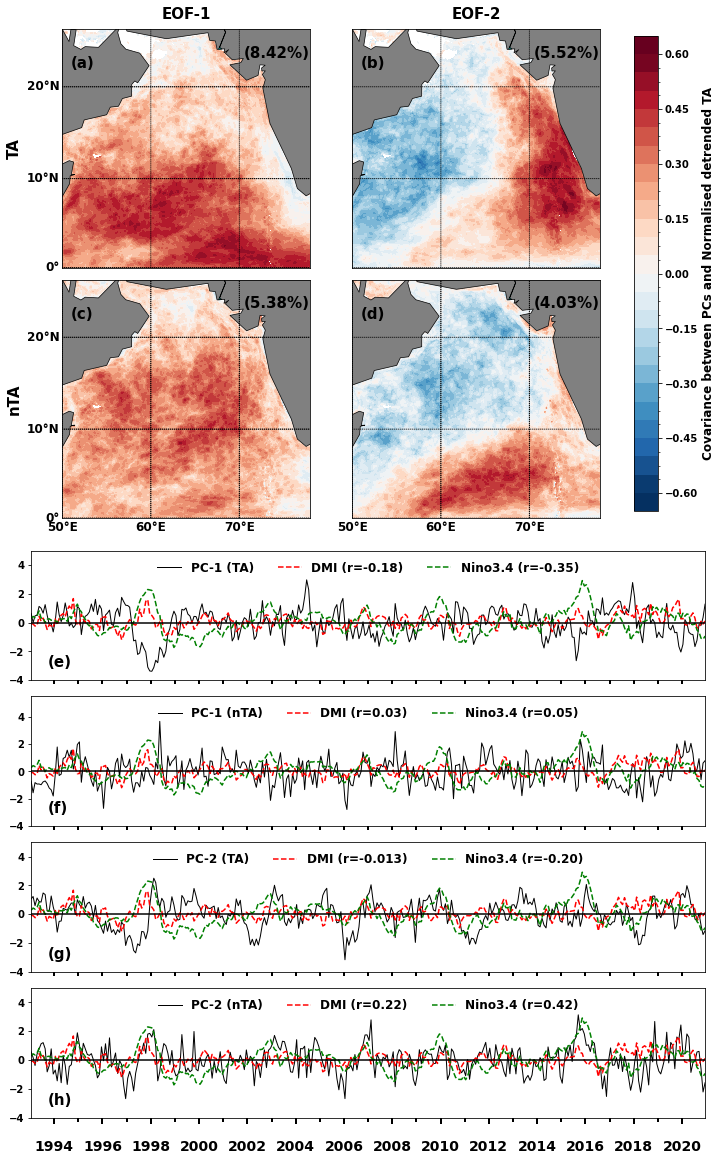

In [285]:
plt.rcParams['font.weight']='bold'

tim=ta.Time
lev=np.arange(-.6,.601,0.05)
from mpl_toolkits.basemap import Basemap
map = Basemap(projection='merc', llcrnrlat=0, urcrnrlat=26,
            llcrnrlon=50, urcrnrlon=78, resolution='c')
lon5,lat5=np.meshgrid(EoF_TA_AS[0].Lon,EoF_TA_AS[0].Lat)
lon5,lat5=map(lon5,lat5)
fig,ax = plt.subplots(2,2,figsize=(12,9))
ax=ax.ravel()
#ax[0].contourf(lon,lat,eof1.sel(mode=0).squeeze(),55,cmap='gist_rainbow_r')

p1=ax[0].contourf(lon5,lat5,-EoF_TA_AS[0].sel(mode=0).squeeze(),55,cmap='RdBu_r',extend='both',levels=lev)
ax[1].contourf(lon5,lat5,EoF_TA_AS[0].sel(mode=1).squeeze(),55,cmap='RdBu_r',levels=lev,extend='both')

p11=ax[2].contourf(lon5,lat5,EoF_nTA_AS[0].sel(mode=0).squeeze(),55,cmap='RdBu_r',extend='both',levels=lev)
ax[3].contourf(lon5,lat5,EoF_nTA_AS[0].sel(mode=1).squeeze(),55,cmap='RdBu_r',levels=lev,extend='both')


fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace= -0.1, hspace=0.05)  
for i in range(4):      
    map.drawcoastlines(linewidth=0.7,color='k', ax=ax[i])
    map.fillcontinents(color='grey',lake_color='aqua', ax=ax[i])
    ax[i].tick_params(axis='both', labelsize=8)
    map.drawmeridians(np.arange(30, 120,10), color='black', fontsize=16, ax=ax[i])
    map.drawparallels(np.arange(-30, 30, 10), color='black', fontsize=16, ax=ax[i])
    if i in [2,3]:
        map.drawmeridians(np.arange(30, 120, 10), labels=[0,0,0,1], color='black', fontsize=12, ax=ax[i])
    if i in [0,2]:
        map.drawparallels(np.arange(-30, 30, 10), labels=[1,0,0,0], color='black', fontsize=12, ax=ax[i])
    

ax[1].set_yticks([])

cb2 = fig.colorbar(p1, ax=ax[:], extend='both', extendfrac='auto', extendrect=True, fraction = 0.0355)
cb2.ax.tick_params(labelsize=10)
cb2.minorticks_on()  
cb2.set_label('Covariance between PCs and Normalised detrended TA', rotation=90,fontsize=12,fontweight='bold')

# cax2 = fig.add_axes([.17, 0.05, 0.675, 0.035])
# cb2=plt.colorbar(p1,cax=cax2,extend=None,ticks=np.arange(-.6,.601,.1),pad=0.5,orientation='horizontal')
# cb2.ax.tick_params(labelsize=10)
# cb2.minorticks_on()  
# cb2.set_label('Covariance between PCs and Normalised detrended TA', rotation=0,fontsize=12,fontweight='bold')

# #plt.colorbar()

left, bottom, width, height = [0.175, -0.125, .78, 0.2]
ax1 = fig.add_axes([left, bottom, width, height])
ax1.margins(x=0)
ax1.plot(tim,-EoF_TA_AS[1].sel(mode=0),c='black',label='PC-1',linewidth=1)
# ax1.plot(tim,EoF_nTA_AS[1].sel(mode=0),c='r',label='PC-1')

ax1.plot(tim,dmi,c='red',linestyle='--')
ax1.plot(tim,nino,c='g',linestyle='--')
ax1.legend(['PC-1 (TA)','DMI (r=-0.18)','Nino3.4 (r=-0.35)'],ncol=3,loc='upper center',framealpha=0,fontsize=12)
ax1.axhline(y=0,c='black')
ax1.set_ylim([-4,5])


# ax1.xaxis.set_major_locator(MonthLocator(bymonth=7,bymonthday=16)


ax1.xaxis.set_minor_locator(YearLocator(2,month=1,day=1))
ax1.tick_params(axis='x',which='minor',length=5, width=2,labelsize=10,rotation=45)
# ax1.xaxis.set_minor_formatter(DateFormatter("\n%Y"))
ax1.xaxis.set_tick_params(which='minor',labelsize=12,rotation=45)
# ax1.set_ylabel('PC-1',fontweight='bold',fontsize=12)
ax1.set_xticks([])



left, bottom, width, height = [0.175, -.35, .78, 0.2]
ax2 = fig.add_axes([left, bottom, width, height])
ax2.margins(x=0)
ax2.plot(tim,EoF_nTA_AS[1].sel(mode=0),c='black',linewidth=1)
# ax2.plot(tim,EoF_nTA_AS[1].sel(mode=1),c='r',linewidth=2)
ax2.plot(tim,dmi,c='r',linestyle='--')
ax2.plot(tim,nino,c='g',linestyle='--')
ax2.legend(['PC-1 (nTA)','DMI (r=0.03)','Nino3.4 (r=0.05)'],ncol=3,loc='upper center',framealpha=0,fontsize=12)
ax2.axhline(y=0,c='black')
ax2.set_ylim([-4,5.5])


ax2.xaxis.set_minor_locator(YearLocator(2,month=1,day=15))
ax2.tick_params(axis='x',which='minor',length=5, width=2,labelsize=10,rotation=45)
ax2.xaxis.set_tick_params(labelsize=12,rotation=45)
# ax1.set_ylabel('PC-1',fontweight='bold',fontsize=12)
ax2.set_xticks([])




left, bottom, width, height = [0.175, -0.575, .78, 0.2]
ax3 = fig.add_axes([left, bottom, width, height])
ax3.margins(x=0)
ax3.plot(tim,EoF_TA_AS[1].sel(mode=1),c='black',label='PC-2',linewidth=1)
# ax1.plot(tim,EoF_nTA_AS[1].sel(mode=0),c='r',label='PC-1')

ax3.plot(tim,dmi,c='red',linestyle='--')
ax3.plot(tim,nino,c='g',linestyle='--')
ax3.legend(['PC-2 (TA)','DMI (r=-0.013)','Nino3.4 (r=-0.20)'],ncol=3,loc='upper center',framealpha=0,fontsize=12)
ax3.axhline(y=0,c='black')
ax3.set_ylim([-4,5])



left, bottom, width, height = [0.175, -0.8, .78, 0.2]
ax4 = fig.add_axes([left, bottom, width, height])
ax4.margins(x=0)
ax4.plot(tim,EoF_nTA_AS[1].sel(mode=1),c='black',label='PC-2',linewidth=1)
# ax1.plot(tim,EoF_nTA_AS[1].sel(mode=0),c='r',label='PC-1')

ax4.plot(tim,dmi,c='red',linestyle='--')
ax4.plot(tim,nino,c='g',linestyle='--')
ax4.legend(['PC-2 (nTA)','DMI (r=0.22)','Nino3.4 (r=0.42)'],ncol=3,loc='upper center',framealpha=0,fontsize=12)
ax4.axhline(y=0,c='black')
ax4.set_ylim([-4,5])



# left, bottom, width, height = [0.125, -1.4, .78, 0.4]
# ax3 = fig.add_axes([left, bottom, width, height])
# ax3.margins(x=0)
# ax3.plot(tim,pc2.sel(mode=2).squeeze(),c='black')
# ax3.plot(tim,dmi,c='red')
# ax3.plot(tim,nino,c='blue')
# ax3.legend(['PC-3','DMI (r=-0.13)','Nino3.4 (r=-0.18)'],ncol=3,loc='lower center',framealpha=0,fontsize=12)
# ax3.axhline(y=0,c='black')
# ax3.set_ylim([-4,4])
# ax3.set_xticks([])

ax1.text(0.73,.88,'(8.42%)',fontsize=15,fontweight='bold',transform=ax[0].transAxes)
ax2.text(0.73,.88,'(5.52%)',fontsize=15,fontweight='bold',transform=ax[1].transAxes)

ax[2].text(0.73,.88,'(5.38%)',fontsize=15,fontweight='bold',transform=ax[2].transAxes)
ax[3].text(0.73,.88,'(4.03%)',fontsize=15,fontweight='bold',transform=ax[3].transAxes)

# ax3.text(1.45,1.02,'EOF-3 (variance=4.27%)',fontsize=12,fontweight='bold',transform=ax[1].transAxes)

ax[0].set_ylabel('TA',fontsize=15,fontweight='bold',labelpad=40)
ax[2].set_ylabel('nTA',fontsize=15,fontweight='bold',labelpad=40)

ax[0].set_title('EOF-1',fontsize=15,fontweight='bold',pad=10)
ax[1].set_title('EOF-2',fontsize=15,fontweight='bold',pad=10)


xx,yy=map(51,22)
ax[0].text(xx,yy,'(a)',fontsize=15)
ax[1].text(xx,yy,'(b)',fontsize=15)
ax[2].text(xx,yy,'(c)',fontsize=15)
ax[3].text(xx,yy,'(d)',fontsize=15)


ax1.text(0.025,0.1,'(e)',fontsize=15,transform=ax1.transAxes)
ax2.text(0.025,0.1,'(f)',fontsize=15,transform=ax2.transAxes)
ax3.text(0.025,0.1,'(g)',fontsize=15,transform=ax3.transAxes)
ax4.text(0.025,0.1,'(h)',fontsize=15,transform=ax4.transAxes)


for i, ax in enumerate([ax1,ax2,ax3,ax4]):
        ax.xaxis.set_major_locator(YearLocator(2))
        ax.tick_params(axis='x',which='major', length=6,width=2,pad=0,labelsize=13)
        ax.xaxis.set_minor_locator(YearLocator(1))
        ax.tick_params(axis='x',which='minor',length=4, width=2,labelsize=13)
        if i in [0,1,2,3]:
#             ax[i].xaxis.set_minor_formatter(FuncFormatter(m_fmt))
            ax.xaxis.set_tick_params(labelsize=14)
        if i in [0,1,2]:
            ax.set_xticks([])
        if i in [3]:
            ax.xaxis.set_major_formatter(DateFormatter("\n%Y"))  

# plt.savefig('EOF_AS_new.png', transparent=None, dpi=400, bbox_inches='tight', facecolor='white', edgecolor='white')            

# BoB

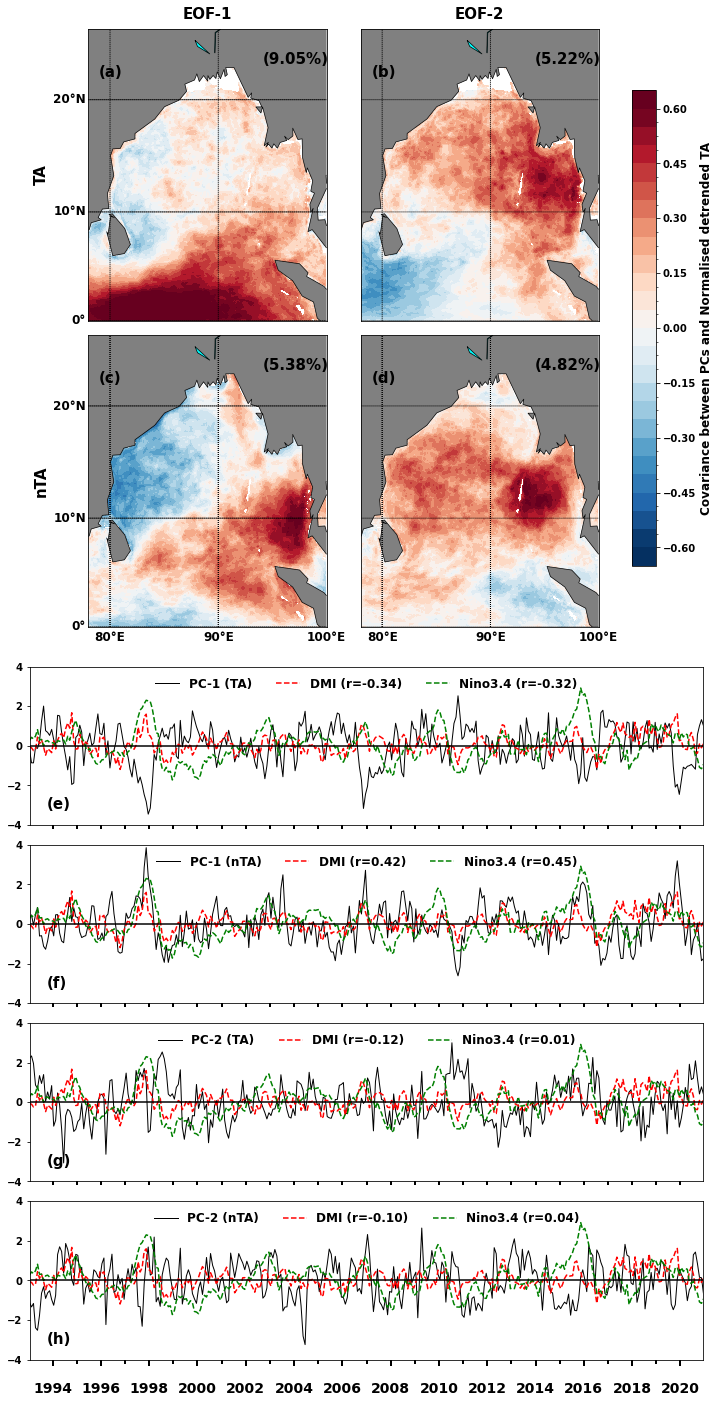

In [303]:
plt.rcParams['font.weight']='bold'

tim=ta.Time
lev=np.arange(-.6,.601,0.05)
from mpl_toolkits.basemap import Basemap
map = Basemap(projection='merc', llcrnrlat=0, urcrnrlat=26,
            llcrnrlon=78, urcrnrlon=100, resolution='c')
lon5,lat5=np.meshgrid(EoF_TA_BoB[0].Lon,EoF_TA_BoB[0].Lat)
lon5,lat5=map(lon5,lat5)
fig,ax = plt.subplots(2,2,figsize=(12,11))
ax=ax.ravel()
#ax[0].contourf(lon,lat,eof1.sel(mode=0).squeeze(),55,cmap='gist_rainbow_r')

p1=ax[0].contourf(lon5,lat5,EoF_TA_BoB[0].sel(mode=0).squeeze(),55,cmap='RdBu_r',extend='both',levels=lev)
ax[1].contourf(lon5,lat5,EoF_TA_BoB[0].sel(mode=1).squeeze(),55,cmap='RdBu_r',levels=lev,extend='both')

p11=ax[2].contourf(lon5,lat5,EoF_nTA_BoB[0].sel(mode=0).squeeze(),55,cmap='RdBu_r',extend='both',levels=lev)
ax[3].contourf(lon5,lat5,EoF_nTA_BoB[0].sel(mode=1).squeeze(),55,cmap='RdBu_r',levels=lev,extend='both')


fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace= -0.2, hspace=0.05)  
for i in range(4):      
    map.drawcoastlines(linewidth=0.7,color='k', ax=ax[i])
    map.fillcontinents(color='grey',lake_color='aqua', ax=ax[i])
    ax[i].tick_params(axis='both', labelsize=8)
    map.drawmeridians(np.arange(30, 120,10), color='black', fontsize=16, ax=ax[i])
    map.drawparallels(np.arange(-30, 30, 10), color='black', fontsize=16, ax=ax[i])
    if i in [2,3]:
        map.drawmeridians(np.arange(30, 120, 10), labels=[0,0,0,1], color='black', fontsize=12, ax=ax[i])
    if i in [0,2]:
        map.drawparallels(np.arange(-30, 30, 10), labels=[1,0,0,0], color='black', fontsize=12, ax=ax[i])
    

ax[1].set_yticks([])

cb2 = fig.colorbar(p1, ax=ax[:], extend='both', extendfrac='auto', extendrect=True, fraction = 0.0355)
cb2.ax.tick_params(labelsize=10)
cb2.minorticks_on()  
cb2.set_label('Covariance between PCs and Normalised detrended TA', rotation=90,fontsize=12,fontweight='bold')

# cax2 = fig.add_axes([.17, 0.05, 0.675, 0.035])
# cb2=plt.colorbar(p1,cax=cax2,extend=None,ticks=np.arange(-.6,.601,.1),pad=0.5,orientation='horizontal')
# cb2.ax.tick_params(labelsize=10)
# cb2.minorticks_on()  
# cb2.set_label('Covariance between PCs and Normalised detrended TA', rotation=0,fontsize=12,fontweight='bold')

# #plt.colorbar()

left, bottom, width, height = [0.175, -0.125, .78, 0.2]
ax1 = fig.add_axes([left, bottom, width, height])
ax1.margins(x=0)
ax1.plot(tim,EoF_TA_BoB[1].sel(mode=0),c='black',label='PC-1',linewidth=1)
# ax1.plot(tim,EoF_nTA_BoB[1].sel(mode=0),c='r',label='PC-1')

ax1.plot(tim,dmi,c='red',linestyle='--')
ax1.plot(tim,nino,c='g',linestyle='--')
ax1.legend(['PC-1 (TA)','DMI (r=-0.34)','Nino3.4 (r=-0.32)'],ncol=3,loc='upper center',framealpha=0,fontsize=12)
ax1.axhline(y=0,c='black')
ax1.set_ylim([-4,4])


# ax1.xaxis.set_major_locator(MonthLocator(bymonth=7,bymonthday=16)


ax1.xaxis.set_minor_locator(YearLocator(2,month=1,day=1))
ax1.tick_params(axis='x',which='minor',length=5, width=2,labelsize=10,rotation=45)
# ax1.xaxis.set_minor_formatter(DateFormatter("\n%Y"))
ax1.xaxis.set_tick_params(which='minor',labelsize=12,rotation=45)
# ax1.set_ylabel('PC-1',fontweight='bold',fontsize=12)
ax1.set_xticks([])



left, bottom, width, height = [0.175, -.35, .78, 0.2]
ax2 = fig.add_axes([left, bottom, width, height])
ax2.margins(x=0)
ax2.plot(tim,EoF_nTA_BoB[1].sel(mode=0),c='black',linewidth=1)
# ax2.plot(tim,EoF_nTA_BoB[1].sel(mode=1),c='r',linewidth=2)
ax2.plot(tim,dmi,c='r',linestyle='--')
ax2.plot(tim,nino,c='g',linestyle='--')
ax2.legend(['PC-1 (nTA)','DMI (r=0.42)','Nino3.4 (r=0.45)'],ncol=3,loc='upper center',framealpha=0,fontsize=12)
ax2.axhline(y=0,c='black')
ax2.set_ylim([-4,4])


ax2.xaxis.set_minor_locator(YearLocator(2,month=1,day=15))
ax2.tick_params(axis='x',which='minor',length=5, width=2,labelsize=10,rotation=45)
ax2.xaxis.set_tick_params(labelsize=12,rotation=45)
# ax1.set_ylabel('PC-1',fontweight='bold',fontsize=12)
ax2.set_xticks([])




left, bottom, width, height = [0.175, -0.575, .78, 0.2]
ax3 = fig.add_axes([left, bottom, width, height])
ax3.margins(x=0)
ax3.plot(tim,EoF_TA_BoB[1].sel(mode=1),c='black',label='PC-2',linewidth=1)
# ax1.plot(tim,EoF_nTA_BoB[1].sel(mode=0),c='r',label='PC-1')

ax3.plot(tim,dmi,c='red',linestyle='--')
ax3.plot(tim,nino,c='g',linestyle='--')
ax3.legend(['PC-2 (TA)','DMI (r=-0.12)','Nino3.4 (r=0.01)'],ncol=3,loc='upper center',framealpha=0,fontsize=12)
ax3.axhline(y=0,c='black')
ax3.set_ylim([-4,4])



left, bottom, width, height = [0.175, -0.8, .78, 0.2]
ax4 = fig.add_axes([left, bottom, width, height])
ax4.margins(x=0)
ax4.plot(tim,EoF_nTA_BoB[1].sel(mode=1),c='black',label='PC-2',linewidth=1)
# ax1.plot(tim,EoF_nTA_BoB[1].sel(mode=0),c='r',label='PC-1')

ax4.plot(tim,dmi,c='red',linestyle='--')
ax4.plot(tim,nino,c='g',linestyle='--')
ax4.legend(['PC-2 (nTA)','DMI (r=-0.10)','Nino3.4 (r=0.04)'],ncol=3,loc='upper center',framealpha=0,fontsize=12)
ax4.axhline(y=0,c='black')
ax4.set_ylim([-4,4])



# left, bottom, width, height = [0.125, -1.4, .78, 0.4]
# ax3 = fig.add_axes([left, bottom, width, height])
# ax3.margins(x=0)
# ax3.plot(tim,pc2.sel(mode=2).squeeze(),c='black')
# ax3.plot(tim,dmi,c='red')
# ax3.plot(tim,nino,c='blue')
# ax3.legend(['PC-3','DMI (r=-0.13)','Nino3.4 (r=-0.18)'],ncol=3,loc='lower center',framealpha=0,fontsize=12)
# ax3.axhline(y=0,c='black')
# ax3.set_ylim([-4,4])
# ax3.set_xticks([])

ax1.text(0.73,.88,'(9.05%)',fontsize=15,fontweight='bold',transform=ax[0].transAxes)
ax2.text(0.73,.88,'(5.22%)',fontsize=15,fontweight='bold',transform=ax[1].transAxes)

ax[2].text(0.73,.88,'(5.38%)',fontsize=15,fontweight='bold',transform=ax[2].transAxes)
ax[3].text(0.73,.88,'(4.82%)',fontsize=15,fontweight='bold',transform=ax[3].transAxes)

# ax3.text(1.45,1.02,'EOF-3 (variance=4.27%)',fontsize=12,fontweight='bold',transform=ax[1].transAxes)

ax[0].set_ylabel('TA',fontsize=15,fontweight='bold',labelpad=40)
ax[2].set_ylabel('nTA',fontsize=15,fontweight='bold',labelpad=40)

ax[0].set_title('EOF-1',fontsize=15,fontweight='bold',pad=10)
ax[1].set_title('EOF-2',fontsize=15,fontweight='bold',pad=10)


xx,yy=map(79,22)
ax[0].text(xx,yy,'(a)',fontsize=15)
ax[1].text(xx,yy,'(b)',fontsize=15)
ax[2].text(xx,yy,'(c)',fontsize=15)
ax[3].text(xx,yy,'(d)',fontsize=15)


ax1.text(0.025,0.1,'(e)',fontsize=15,transform=ax1.transAxes)
ax2.text(0.025,0.1,'(f)',fontsize=15,transform=ax2.transAxes)
ax3.text(0.025,0.1,'(g)',fontsize=15,transform=ax3.transAxes)
ax4.text(0.025,0.1,'(h)',fontsize=15,transform=ax4.transAxes)


for i, ax in enumerate([ax1,ax2,ax3,ax4]):
        ax.xaxis.set_major_locator(YearLocator(2))
        ax.tick_params(axis='x',which='major', length=6,width=2,pad=0,labelsize=13)
        ax.xaxis.set_minor_locator(YearLocator(1))
        ax.tick_params(axis='x',which='minor',length=4, width=2,labelsize=13)
        if i in [0,1,2,3]:
#             ax[i].xaxis.set_minor_formatter(FuncFormatter(m_fmt))
            ax.xaxis.set_tick_params(labelsize=14)
        if i in [0,1,2]:
            ax.set_xticks([])
        if i in [3]:
            ax.xaxis.set_major_formatter(DateFormatter("\n%Y"))  

# plt.savefig('EOF_BoB_new.png', transparent=None, dpi=400, bbox_inches='tight', facecolor='white', edgecolor='white')  

# NIO

In [ ]:
# fig,ax=plt.subplots(figsize=(14,3))
# ay=ax.twinx()
# ax.plot((ta-clim).sel(Lon=slice(50,78)).mean(dim=['Lon','Lat']),c='red')
# ax.plot(detrend_TA.sel(Lon=slice(50,78)).mean(dim=['Lon','Lat']),c='g')

In [ ]:
# np.corrcoef((ta-clim).sel(Lon=slice(50,78)).mean(dim=['Lon','Lat']),detrend_TA.sel(Lon=slice(50,78)).mean(dim=['Lon','Lat']))

In [ ]:
# np.corrcoef((ta-clim).sel(Lon=slice(78,100)).mean(dim=['Lon','Lat']),detrend_TA.sel(Lon=slice(78,100)).mean(dim=['Lon','Lat']))

In [ ]:
# mask=data[0].notnull()
# mask.plot()

# AS nTA (old)

In [167]:
data=(new_ta-clim_nTA)/clim_std_nTA
    
data=data.sel(Lon=slice(50,78))
coslat = np.cos(np.deg2rad(data.coords['Lat'].values))
wgts = np.sqrt(coslat)[..., np.newaxis]
solver = Eof(data,weights=wgts,center=True)
# eof1 = solver.eofsAsCorrelation(neofs=3)
# pc1 = solver.pcs(npcs=3, pcscaling=1)
eof2 = solver.eofsAsCovariance(neofs=3)
pc2 = solver.pcs(npcs=3, pcscaling=1)
variance_fractions = solver.varianceFraction()
print(variance_fractions[0:3]*100)
for i in range(3):
    print(np.corrcoef(dmi,pc2[:,i].sel(Time=slice('1993','2020')))[0][1])
print('\n','Nino3.4','\n')    
for i in range(3):
    print(np.corrcoef(nino,pc2[:,i].sel(Time=slice('1993','2020')))[0][1])

<xarray.DataArray 'variance_fractions' (mode: 3)>
array([5.3896527, 3.909913 , 2.4403238], dtype=float32)
Coordinates:
  * mode     (mode) int64 0 1 2
-0.03090047308566033
0.2288397888335515
0.15953059518875953

 Nino3.4 

-0.05567315904156416
0.4207165522005825
-0.08114176594798055


# AS TA (old)

In [ ]:
data=(ta-clim)/clim_std
# data=data.interpolate_na(dim='Time')
# data=data.interpolate_na(dim='Lat')
# data=data.interpolate_na(dim='Lon')
# data=(data*mask).where((data*mask)!=0)
data=data.sel(Lon=slice(50,78))
coslat = np.cos(np.deg2rad(data.coords['Lat'].values))
wgts = np.sqrt(coslat)[..., np.newaxis]
solver = Eof(data,weights=wgts,center=True)
# eof1 = solver.eofsAsCorrelation(neofs=3)
# pc1 = solver.pcs(npcs=3, pcscaling=1)
eof2 = solver.eofsAsCovariance(neofs=3)
pc2 = solver.pcs(npcs=3, pcscaling=1)
variance_fractions = solver.varianceFraction()
print(variance_fractions[0:3]*100)
for i in range(3):
    print(np.corrcoef(dmi,pc2[:,i].sel(Time=slice('1993','2020')))[0][1])
print('\n','Nino3.4','\n')    
for i in range(3):
    print(np.corrcoef(nino,pc2[:,i].sel(Time=slice('1993','2020')))[0][1])

In [ ]:
# data.to_netcdf('normalised_ta_AS.nc')
# import subprocess
# comm="cdo eof,3 normalised_ta_AS.nc eigval_AS.nc pattern_AS.nc"
# subprocess.run(comm,shell=True)

In [ ]:
#####################For 3 modes #########################################################
plt.rcParams['font.weight']='bold'

tim=ta.Time
lev=np.arange(-.4,.4,0.05)
from mpl_toolkits.basemap import Basemap
map = Basemap(projection='merc', llcrnrlat=0, urcrnrlat=26,
            llcrnrlon=50, urcrnrlon=78, resolution='c')
lon5,lat5=np.meshgrid(eof2.Lon,eof2.Lat)
lon5,lat5=map(lon5,lat5)
fig,ax = plt.subplots(1,3,figsize=(16,5.5))
#ax[0].contourf(lon,lat,eof1.sel(mode=0).squeeze(),55,cmap='gist_rainbow_r')
p1=ax[0].contourf(lon5,lat5,eof2.sel(mode=0).squeeze(),55,cmap='RdBu_r',extend='both',levels=lev)
ax[1].contourf(lon5,lat5,eof2.sel(mode=1).squeeze(),55,cmap='RdBu_r',levels=lev,extend='both')
ax[2].contourf(lon5,lat5,eof2.sel(mode=2).squeeze(),55,cmap='RdBu_r',levels=lev,extend='both')

fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.14, hspace=0.05)  
for i in range(3):      
    map.drawcoastlines(linewidth=0.7,color='k', ax=ax[i])
    map.fillcontinents(color='grey',lake_color='aqua', ax=ax[i])
    ax[i].tick_params(axis='both', labelsize=8)
    map.drawmeridians(np.arange(30, 120,10), color='black', fontsize=16, ax=ax[i])
    map.drawparallels(np.arange(-30, 30, 10), color='black', fontsize=16, ax=ax[i])
    if i in [0,1,2]:
        map.drawmeridians(np.arange(30, 120, 10), labels=[0,0,0,1], color='black', fontsize=12, ax=ax[i])
    if i in [0]:
        map.drawparallels(np.arange(-30, 30, 10), labels=[1,0,0,0], color='black', fontsize=12, ax=ax[i])
    

ax[1].set_yticks([])
cax2 = fig.add_axes([.215, 0.05, 0.6, 0.035])
cb2=plt.colorbar(p1,cax=cax2,extend=None,ticks=np.arange(-.4,.4,.05),pad=0.5,orientation='horizontal')
cb2.ax.tick_params(labelsize=10)
cb2.minorticks_on()  
cb2.set_label('Covariance between PCs and Normalised detrended TA', rotation=0,fontsize=12,fontweight='bold')
# #plt.colorbar()

left, bottom, width, height = [0.125, -0.5, .78, 0.4]
ax1 = fig.add_axes([left, bottom, width, height])
ax1.margins(x=0)
ax1.plot(tim,pc2.sel(mode=0).squeeze(),c='black',label='PC-1')
ax1.plot(tim,dmi,c='red')
ax1.plot(tim,nino,c='blue')
ax1.legend(['PC-1','DMI (r=0.18)','Nino3.4 (r=0.35)'],ncol=3,loc='lower center',framealpha=0,fontsize=12)
ax1.axhline(y=0,c='black')
ax1.set_ylim([-4,4])


# ax1.xaxis.set_major_locator(MonthLocator(bymonth=7,bymonthday=16)


ax1.xaxis.set_minor_locator(YearLocator(2,month=1,day=1))
ax1.tick_params(axis='x',which='minor',length=5, width=2,labelsize=10,rotation=45)
# ax1.xaxis.set_minor_formatter(DateFormatter("\n%Y"))
ax1.xaxis.set_tick_params(which='minor',labelsize=12,rotation=45)
# ax1.set_ylabel('PC-1',fontweight='bold',fontsize=12)
ax1.set_xticks([])



left, bottom, width, height = [0.125, -.95, .78, 0.4]
ax2 = fig.add_axes([left, bottom, width, height])
ax2.margins(x=0)
ax2.plot(tim,pc2.sel(mode=1).squeeze(),c='black')
ax2.plot(tim,dmi,c='red')
ax2.plot(tim,-nino,c='blue')
ax2.legend(['PC-2','DMI (r=-0.013)','Nino3.4 (r=0.20)'],ncol=3,loc='lower center',framealpha=0,fontsize=12)
ax2.axhline(y=0,c='black')
ax2.set_ylim([-4,4])


ax2.xaxis.set_minor_locator(YearLocator(2,month=1,day=15))
ax2.tick_params(axis='x',which='minor',length=5, width=2,labelsize=10,rotation=45)
ax2.xaxis.set_tick_params(labelsize=12,rotation=45)
# ax1.set_ylabel('PC-1',fontweight='bold',fontsize=12)
ax2.set_xticks([])


left, bottom, width, height = [0.125, -1.4, .78, 0.4]
ax3 = fig.add_axes([left, bottom, width, height])
ax3.margins(x=0)
ax3.plot(tim,pc2.sel(mode=2).squeeze(),c='black')
ax3.plot(tim,dmi,c='red')
ax3.plot(tim,nino,c='blue')
ax3.legend(['PC-3','DMI (r=-0.13)','Nino3.4 (r=-0.18)'],ncol=3,loc='lower center',framealpha=0,fontsize=12)
ax3.axhline(y=0,c='black')
ax3.set_ylim([-4,4])
ax3.set_xticks([])

ax1.text(0.3,1.02,'EOF-1 (variance=8.42%)',fontsize=12,fontweight='bold',transform=ax[0].transAxes)
ax2.text(0.3,1.02,'EOF-2 (variance=5.52%)',fontsize=12,fontweight='bold',transform=ax[1].transAxes)
ax3.text(1.45,1.02,'EOF-3 (variance=4.27%)',fontsize=12,fontweight='bold',transform=ax[1].transAxes)


xx,yy=map(51,22)
ax[0].text(xx,yy,'(a)',fontsize=15)
ax[1].text(xx,yy,'(b)',fontsize=15)
ax[2].text(xx,yy,'(c)',fontsize=15)

ax1.text(0.025,0.1,'(d)',fontsize=15,transform=ax1.transAxes)
ax2.text(0.025,0.1,'(e)',fontsize=15,transform=ax2.transAxes)
ax3.text(0.025,0.1,'(f)',fontsize=15,transform=ax3.transAxes)


for i, ax in enumerate([ax1,ax2,ax3]):
        ax.xaxis.set_major_locator(YearLocator(2))
        ax.tick_params(axis='x',which='major', length=6,width=2,pad=0,labelsize=13)
        ax.xaxis.set_minor_locator(YearLocator(1))
        ax.tick_params(axis='x',which='minor',length=4, width=2,labelsize=13)
        if i in [0,1]:
#             ax[i].xaxis.set_minor_formatter(FuncFormatter(m_fmt))
            ax.xaxis.set_tick_params(labelsize=14)
        if i in [0,1]:
            ax.set_xticks([])
        if i in [2]:
            ax.xaxis.set_major_formatter(DateFormatter("\n%Y"))  

# plt.savefig('EOF_AS.png', transparent=None, dpi=400, bbox_inches='tight', facecolor='white', edgecolor='white')            

In [ ]:
plt.rcParams['font.weight']='bold'

tim=ta.Time
lev=np.arange(-.4,.4,0.05)
from mpl_toolkits.basemap import Basemap
map = Basemap(projection='merc', llcrnrlat=0, urcrnrlat=26,
            llcrnrlon=50, urcrnrlon=78, resolution='c')
lon5,lat5=np.meshgrid(eof2.Lon,eof2.Lat)
lon5,lat5=map(lon5,lat5)
fig,ax = plt.subplots(1,2,figsize=(14,7))

#ax[0].contourf(lon,lat,eof1.sel(mode=0).squeeze(),55,cmap='gist_rainbow_r')
p1=ax[0].contourf(lon5,lat5,-eof2.sel(mode=0).squeeze(),55,cmap='RdBu_r',extend='both',levels=lev)
ax[1].contourf(lon5,lat5,eof2.sel(mode=1).squeeze(),55,cmap='RdBu_r',levels=lev,extend='both')

fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.14, hspace=0.05)  
for i in range(2):      
    map.drawcoastlines(linewidth=0.7,color='k', ax=ax[i])
    map.fillcontinents(color='grey',lake_color='aqua', ax=ax[i])
    ax[i].tick_params(axis='both', labelsize=8)
    map.drawmeridians(np.arange(30, 120,10), color='black', fontsize=16, ax=ax[i])
    map.drawparallels(np.arange(-30, 30, 10), color='black', fontsize=16, ax=ax[i])
    if i in [0,1]:
        map.drawmeridians(np.arange(30, 120, 10), labels=[0,0,0,1], color='black', fontsize=12, ax=ax[i])
    if i in [0]:
        map.drawparallels(np.arange(-30, 30, 10), labels=[1,0,0,0], color='black', fontsize=12, ax=ax[i])
    

ax[1].set_yticks([])
cax2 = fig.add_axes([.17, 0.05, 0.675, 0.035])
cb2=plt.colorbar(p1,cax=cax2,extend=None,ticks=np.arange(-.4,.4,.05),pad=0.5,orientation='horizontal')
cb2.ax.tick_params(labelsize=10)
cb2.minorticks_on()  
cb2.set_label('Covariance between PCs and Normalised detrended TA', rotation=0,fontsize=12,fontweight='bold')
# #plt.colorbar()

left, bottom, width, height = [0.125, -0.5, .78, 0.4]
ax1 = fig.add_axes([left, bottom, width, height])
ax1.margins(x=0)
ax1.plot(tim,-pc2.sel(mode=0).squeeze(),c='black',label='PC-1')
ax1.plot(tim,dmi,c='red')
ax1.plot(tim,nino,c='blue')
ax1.legend(['PC-1','DMI (r=-0.18)','Nino3.4 (r=-0.35)'],ncol=3,loc='lower center',framealpha=0,fontsize=12)
ax1.axhline(y=0,c='black')
ax1.set_ylim([-4,4])


# ax1.xaxis.set_major_locator(MonthLocator(bymonth=7,bymonthday=16)


ax1.xaxis.set_minor_locator(YearLocator(2,month=1,day=1))
ax1.tick_params(axis='x',which='minor',length=5, width=2,labelsize=10,rotation=45)
# ax1.xaxis.set_minor_formatter(DateFormatter("\n%Y"))
ax1.xaxis.set_tick_params(which='minor',labelsize=12,rotation=45)
# ax1.set_ylabel('PC-1',fontweight='bold',fontsize=12)
ax1.set_xticks([])



left, bottom, width, height = [0.125, -.95, .78, 0.4]
ax2 = fig.add_axes([left, bottom, width, height])
ax2.margins(x=0)
ax2.plot(tim,pc2.sel(mode=1).squeeze(),c='black')
ax2.plot(tim,dmi,c='red')
ax2.plot(tim,nino,c='blue')
ax2.legend(['PC-2','DMI (r=-0.013)','Nino3.4 (r=0.20)'],ncol=3,loc='lower center',framealpha=0,fontsize=12)
ax2.axhline(y=0,c='black')
ax2.set_ylim([-4,4])


ax2.xaxis.set_minor_locator(YearLocator(2,month=1,day=15))
ax2.tick_params(axis='x',which='minor',length=5, width=2,labelsize=10,rotation=45)
ax2.xaxis.set_tick_params(labelsize=12,rotation=45)
# ax1.set_ylabel('PC-1',fontweight='bold',fontsize=12)
ax2.set_xticks([])


# left, bottom, width, height = [0.125, -1.4, .78, 0.4]
# ax3 = fig.add_axes([left, bottom, width, height])
# ax3.margins(x=0)
# ax3.plot(tim,pc2.sel(mode=2).squeeze(),c='black')
# ax3.plot(tim,dmi,c='red')
# ax3.plot(tim,nino,c='blue')
# ax3.legend(['PC-3','DMI (r=-0.13)','Nino3.4 (r=-0.18)'],ncol=3,loc='lower center',framealpha=0,fontsize=12)
# ax3.axhline(y=0,c='black')
# ax3.set_ylim([-4,4])
# ax3.set_xticks([])

ax1.text(0.3,1.02,'EOF-1 (variance=8.42%)',fontsize=12,fontweight='bold',transform=ax[0].transAxes)
ax2.text(0.3,1.02,'EOF-2 (variance=5.52%)',fontsize=12,fontweight='bold',transform=ax[1].transAxes)
# ax3.text(1.45,1.02,'EOF-3 (variance=4.27%)',fontsize=12,fontweight='bold',transform=ax[1].transAxes)


xx,yy=map(51,22)
ax[0].text(xx,yy,'(a)',fontsize=15)
ax[1].text(xx,yy,'(b)',fontsize=15)
# ax[2].text(xx,yy,'(c)',fontsize=15)

ax1.text(0.025,0.1,'(c)',fontsize=15,transform=ax1.transAxes)
ax2.text(0.025,0.1,'(d)',fontsize=15,transform=ax2.transAxes)
# ax3.text(0.025,0.1,'(f)',fontsize=15,transform=ax3.transAxes)


for i, ax in enumerate([ax1,ax2]):
        ax.xaxis.set_major_locator(YearLocator(2))
        ax.tick_params(axis='x',which='major', length=6,width=2,pad=0,labelsize=13)
        ax.xaxis.set_minor_locator(YearLocator(1))
        ax.tick_params(axis='x',which='minor',length=4, width=2,labelsize=13)
        if i in [0,1]:
#             ax[i].xaxis.set_minor_formatter(FuncFormatter(m_fmt))
            ax.xaxis.set_tick_params(labelsize=14)
        if i in [0]:
            ax.set_xticks([])
        if i in [1]:
            ax.xaxis.set_major_formatter(DateFormatter("\n%Y"))  

# plt.savefig('EOF_AS.png', transparent=None, dpi=400, bbox_inches='tight', facecolor='white', edgecolor='white')            

# BoB

In [168]:
data=(new_ta-clim)/clim_std

data=data.sel(Lon=slice(78,100))
coslat = np.cos(np.deg2rad(data.coords['Lat'].values))
wgts = np.sqrt(coslat)[..., np.newaxis]
solver = Eof(data,weights=wgts,center=True)
# eof1 = solver.eofsAsCorrelation(neofs=3)
# pc1 = solver.pcs(npcs=3, pcscaling=1)
eof2 = solver.eofsAsCovariance(neofs=3)
pc2 = solver.pcs(npcs=3, pcscaling=1)
variance_fractions = solver.varianceFraction()
print(variance_fractions[0:3]*100)

print('\n','DMI','\n')    

for i in range(3):
    print(np.corrcoef(dmi,pc2[:,i].sel(Time=slice('1993','2020')))[0][1])
print('\n','Nino3.4','\n')    
for i in range(3):
    print(np.corrcoef(nino,pc2[:,i].sel(Time=slice('1993','2020')))[0][1])

<xarray.DataArray 'variance_fractions' (mode: 3)>
array([5.3823   , 4.824086 , 3.8318424], dtype=float32)
Coordinates:
  * mode     (mode) int64 0 1 2

 DMI 

0.4258682035481016
-0.10003404439016511
-0.05381801903969952

 Nino3.4 

0.45566878203696054
0.04315857597886139
0.2352928649063636


In [ ]:
plt.rcParams['font.weight']='bold'
lon5,lat5=np.meshgrid(eof2.Lon,eof2.Lat)
lon5,lat5=map(lon5,lat5)
tim=ta.Time
lev=np.arange(-.6,.6,0.05)
from mpl_toolkits.basemap import Basemap
map = Basemap(projection='merc', llcrnrlat=0, urcrnrlat=26,
            llcrnrlon=78, urcrnrlon=100, resolution='c')
fig,ax = plt.subplots(1,3,figsize=(14,5.5))
#ax[0].contourf(lon,lat,eof1.sel(mode=0).squeeze(),55,cmap='gist_rainbow_r')
p1=ax[0].contourf(lon5,lat5,eof2.sel(mode=0).squeeze(),55,cmap='RdBu_r',extend='both',levels=lev)
ax[1].contourf(lon5,lat5,eof2.sel(mode=1).squeeze(),55,cmap='RdBu_r',levels=lev,extend='both')
ax[2].contourf(lon5,lat5,eof2.sel(mode=2).squeeze(),55,cmap='RdBu_r',levels=lev,extend='both')

fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.1, hspace=0.05)  
for i in range(3):      
    map.drawcoastlines(linewidth=0.7,color='k', ax=ax[i])
    map.fillcontinents(color='gray',lake_color='aqua', ax=ax[i])
    ax[i].tick_params(axis='both', labelsize=8)
    map.drawmeridians(np.arange(30, 120,10), color='black', fontsize=16, ax=ax[i])
    map.drawparallels(np.arange(-30, 30, 10), color='black', fontsize=16, ax=ax[i])
    if i in [0,1,2]:
        map.drawmeridians(np.arange(30, 120, 10), labels=[0,0,0,1], color='black', fontsize=12, ax=ax[i])
    if i in [0]:
        map.drawparallels(np.arange(-30, 30, 10), labels=[1,0,0,0], color='black', fontsize=12, ax=ax[i])
    

ax[1].set_yticks([])
cax2 = fig.add_axes([.215, 0.0, 0.6, 0.035])
cb2=plt.colorbar(p1,cax=cax2,extend=None,ticks=np.arange(-.6,.6,.1),pad=0.5,orientation='horizontal')
cb2.ax.tick_params(labelsize=10)
cb2.minorticks_on()  
cb2.set_label('Covariance between PCs and Normalised detrended TA', rotation=0,fontsize=12,fontweight='bold')
# #plt.colorbar()

left, bottom, width, height = [0.125, -0.5, .78, 0.4]
ax1 = fig.add_axes([left, bottom, width, height])
ax1.margins(x=0)
ax1.plot(tim,pc2.sel(mode=0).squeeze(),c='black',label='PC-1')
ax1.plot(tim,dmi,c='red')
ax1.plot(tim,nino,c='blue')
ax1.legend(['PC-1','DMI (r=-0.34)','Nino3.4 (r=-0.42)'],ncol=3,loc='lower center',framealpha=0,fontsize=12)
ax1.axhline(y=0,c='black')
ax1.set_ylim([-4,4])


# ax1.xaxis.set_major_locator(MonthLocator(bymonth=7,bymonthday=16)


ax1.xaxis.set_minor_locator(YearLocator(2,month=1,day=1))
ax1.tick_params(axis='x',which='minor',length=5, width=2,labelsize=10,rotation=45)
# ax1.xaxis.set_minor_formatter(DateFormatter("\n%Y"))
ax1.xaxis.set_tick_params(which='minor',labelsize=12,rotation=45)
# ax1.set_ylabel('PC-1',fontweight='bold',fontsize=12)
ax1.set_xticks([])



left, bottom, width, height = [0.125, -.95, .78, 0.4]
ax2 = fig.add_axes([left, bottom, width, height])
ax2.margins(x=0)
ax2.plot(tim,pc2.sel(mode=1).squeeze(),c='black')
ax2.plot(tim,dmi,c='red')
ax2.plot(tim,-nino,c='blue')
ax2.legend(['PC-2','DMI (r=-0.12)','Nino3.4 (r=0.01)'],ncol=3,loc='lower center',framealpha=0,fontsize=12)
ax2.axhline(y=0,c='black')
ax2.set_ylim([-4,4])


ax2.xaxis.set_minor_locator(YearLocator(2,month=1,day=15))
ax2.tick_params(axis='x',which='minor',length=5, width=2,labelsize=10,rotation=45)
ax2.xaxis.set_tick_params(labelsize=12,rotation=45)
# ax1.set_ylabel('PC-1',fontweight='bold',fontsize=12)
ax2.set_xticks([])


left, bottom, width, height = [0.125, -1.4, .78, 0.4]
ax3 = fig.add_axes([left, bottom, width, height])
ax3.margins(x=0)
ax3.plot(tim,pc2.sel(mode=2).squeeze(),c='black')
ax3.plot(tim,dmi,c='red')
ax3.plot(tim,nino,c='blue')
ax3.legend(['PC-3','DMI (r=-0.09)','Nino3.4 (r=-0.12)'],ncol=3,loc='lower center',framealpha=0,fontsize=12)
ax3.axhline(y=0,c='black')
ax3.set_ylim([-4,4])


ax1.text(0.3,1.02,'EOF-1 (variance=9.05%)',fontsize=12,fontweight='bold',transform=ax[0].transAxes)
ax2.text(0.3,1.02,'EOF-2 (variance=5.22%)',fontsize=12,fontweight='bold',transform=ax[1].transAxes)
ax3.text(1.4,1.02,'EOF-3 (variance=4.15%)',fontsize=12,fontweight='bold',transform=ax[1].transAxes)


xx,yy=map(80,24)
ax[0].text(xx,yy,'(a)',fontsize=15)
ax[1].text(xx,yy,'(b)',fontsize=15)
ax[2].text(xx,yy,'(c)',fontsize=15)

ax1.text(0.025,0.1,'(d)',fontsize=15,transform=ax1.transAxes)
ax2.text(0.025,0.1,'(e)',fontsize=15,transform=ax2.transAxes)
ax3.text(0.025,0.1,'(f)',fontsize=15,transform=ax3.transAxes)

for i, ax in enumerate([ax1,ax2,ax3]):
        ax.xaxis.set_major_locator(YearLocator(2))
        ax.tick_params(axis='x',which='major', length=6,width=2,pad=0,labelsize=13)
        ax.xaxis.set_minor_locator(YearLocator(1))
        ax.tick_params(axis='x',which='minor',length=4, width=2,labelsize=13)
        if i in [0,1]:
#             ax[i].xaxis.set_minor_formatter(FuncFormatter(m_fmt))
            ax.xaxis.set_tick_params(labelsize=14)
        if i in [0,1]:
            ax.set_xticks([])
        if i in [2]:
            ax.xaxis.set_major_formatter(DateFormatter("\n%Y"))  

# plt.savefig('EOF_BoB.png', transparent=None, dpi=400, bbox_inches='tight', facecolor='white', edgecolor='white')            

In [ ]:
plt.rcParams['font.weight']='bold'

tim=ta.Time
# lev=np.arange(-.4,.4,0.05)
from mpl_toolkits.basemap import Basemap
lev=np.arange(-.6,.6,0.05)
from mpl_toolkits.basemap import Basemap
map = Basemap(projection='merc', llcrnrlat=0, urcrnrlat=26,
            llcrnrlon=78, urcrnrlon=100, resolution='c')
# fig,ax = plt.subplots(1,3,figsize=(14,5.5))
lon5,lat5=np.meshgrid(eof2.Lon,eof2.Lat)
lon5,lat5=map(lon5,lat5)

fig,ax = plt.subplots(1,2,figsize=(12,7))

#ax[0].contourf(lon,lat,eof1.sel(mode=0).squeeze(),55,cmap='gist_rainbow_r')
p1=ax[0].contourf(lon5,lat5,eof2.sel(mode=0).squeeze(),55,cmap='RdBu_r',extend='both',levels=lev)
ax[1].contourf(lon5,lat5,eof2.sel(mode=1).squeeze(),55,cmap='RdBu_r',levels=lev,extend='both')

fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.1, hspace=0.05)  
for i in range(2):      
    map.drawcoastlines(linewidth=0.7,color='k', ax=ax[i])
    map.fillcontinents(color='grey',lake_color='aqua', ax=ax[i])
    ax[i].tick_params(axis='both', labelsize=8)
    map.drawmeridians(np.arange(30, 120,10), color='black', fontsize=16, ax=ax[i])
    map.drawparallels(np.arange(-30, 30, 10), color='black', fontsize=16, ax=ax[i])
    if i in [0,1]:
        map.drawmeridians(np.arange(30, 120, 10), labels=[0,0,0,1], color='black', fontsize=12, ax=ax[i])
    if i in [0]:
        map.drawparallels(np.arange(-30, 30, 10), labels=[1,0,0,0], color='black', fontsize=12, ax=ax[i])
    

ax[1].set_yticks([])
cax2 = fig.add_axes([.17, 0.01, 0.675, 0.035])
cb2=plt.colorbar(p1,cax=cax2,extend=None,ticks=np.arange(-.6,.6,.1),pad=0.5,orientation='horizontal')
cb2.ax.tick_params(labelsize=10)
cb2.minorticks_on()  
cb2.set_label('Covariance between PCs and Normalised detrended TA', rotation=0,fontsize=12,fontweight='bold')
# #plt.colorbar()

left, bottom, width, height = [0.125, -0.5, .78, 0.4]
ax1 = fig.add_axes([left, bottom, width, height])
ax1.margins(x=0)
ax1.plot(tim,-pc2.sel(mode=0).squeeze(),c='black',label='PC-1')
ax1.plot(tim,dmi,c='red')
ax1.plot(tim,nino,c='blue')
ax1.legend(['PC-1','DMI (r=-0.34)','Nino3.4 (r=-0.42)'],ncol=3,loc='lower center',framealpha=0,fontsize=12)
ax1.axhline(y=0,c='black')
ax1.set_ylim([-4,4])


# ax1.xaxis.set_major_locator(MonthLocator(bymonth=7,bymonthday=16)


ax1.xaxis.set_minor_locator(YearLocator(2,month=1,day=1))
ax1.tick_params(axis='x',which='minor',length=5, width=2,labelsize=10,rotation=45)
# ax1.xaxis.set_minor_formatter(DateFormatter("\n%Y"))
ax1.xaxis.set_tick_params(which='minor',labelsize=12,rotation=45)
# ax1.set_ylabel('PC-1',fontweight='bold',fontsize=12)
ax1.set_xticks([])



left, bottom, width, height = [0.125, -.95, .78, 0.4]
ax2 = fig.add_axes([left, bottom, width, height])
ax2.margins(x=0)
ax2.plot(tim,pc2.sel(mode=1).squeeze(),c='black')
ax2.plot(tim,dmi,c='red')
ax2.plot(tim,nino,c='blue')
ax2.legend(['PC-2','DMI (r=-0.12)','Nino3.4 (r=0.01)'],ncol=3,loc='lower center',framealpha=0,fontsize=12)
ax2.axhline(y=0,c='black')
ax2.set_ylim([-4,4])


ax2.xaxis.set_minor_locator(YearLocator(2,month=1,day=15))
ax2.tick_params(axis='x',which='minor',length=5, width=2,labelsize=10,rotation=45)
ax2.xaxis.set_tick_params(labelsize=12,rotation=45)
# ax1.set_ylabel('PC-1',fontweight='bold',fontsize=12)
ax2.set_xticks([])


# left, bottom, width, height = [0.125, -1.4, .78, 0.4]
# ax3 = fig.add_axes([left, bottom, width, height])
# ax3.margins(x=0)
# ax3.plot(tim,pc2.sel(mode=2).squeeze(),c='black')
# ax3.plot(tim,dmi,c='red')
# ax3.plot(tim,nino,c='blue')
# ax3.legend(['PC-3','DMI (r=-0.13)','Nino3.4 (r=-0.18)'],ncol=3,loc='lower center',framealpha=0,fontsize=12)
# ax3.axhline(y=0,c='black')
# ax3.set_ylim([-4,4])
# ax3.set_xticks([])

ax1.text(0.3,1.02,'EOF-1 (variance=9.05%)',fontsize=12,fontweight='bold',transform=ax[0].transAxes)
ax2.text(0.3,1.02,'EOF-2 (variance=5.22%)',fontsize=12,fontweight='bold',transform=ax[1].transAxes)
# ax3.text(1.45,1.02,'EOF-3 (variance=4.27%)',fontsize=12,fontweight='bold',transform=ax[1].transAxes)


xx,yy=map(80,24)
ax[0].text(xx,yy,'(a)',fontsize=15)
ax[1].text(xx,yy,'(b)',fontsize=15)
# ax[2].text(xx,yy,'(c)',fontsize=15)

ax1.text(0.025,0.1,'(c)',fontsize=15,transform=ax1.transAxes)
ax2.text(0.025,0.1,'(d)',fontsize=15,transform=ax2.transAxes)
# ax3.text(0.025,0.1,'(f)',fontsize=15,transform=ax3.transAxes)


for i, ax in enumerate([ax1,ax2]):
        ax.xaxis.set_major_locator(YearLocator(2))
        ax.tick_params(axis='x',which='major', length=6,width=2,pad=0,labelsize=13)
        ax.xaxis.set_minor_locator(YearLocator(1))
        ax.tick_params(axis='x',which='minor',length=4, width=2,labelsize=13)
        if i in [0,1]:
#             ax[i].xaxis.set_minor_formatter(FuncFormatter(m_fmt))
            ax.xaxis.set_tick_params(labelsize=14)
        if i in [0]:
            ax.set_xticks([])
        if i in [1]:
            ax.xaxis.set_major_formatter(DateFormatter("\n%Y"))  

# plt.savefig('EOF_BoB.png', transparent=None, dpi=400, bbox_inches='tight', facecolor='white', edgecolor='white')            

# EoF by detrended deseasonalized

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
def seasonal_decomposition(x):
    if np.all(np.isnan(x)):
            return np.nan_to_num(x)
    result = seasonal_decompose(x, model='additive',period=12)
    return result.seasonal  


In [ ]:
data_3d=ta

season = xr.apply_ufunc(
    seasonal_decomposition,
    data_3d,
    input_core_dims=[['Time']],
    output_core_dims=[['Time']],
    vectorize=True
)
deseasonal_TA = data_3d - season


detrend_TA=deseasonal_TA.fillna(1)
detrend_TA=xt.detrend(detrend_TA,dim='Time',detrend_type='linear')

In [ ]:
def eeof(data):
    coslat = np.cos(np.deg2rad(data.coords['Lat'].values))
    wgts = np.sqrt(coslat)[..., np.newaxis]
    solver = Eof(data,weights=wgts,center=False)
    # eof1 = solver.eofsAsCorrelation(neofs=3)
    # pc1 = solver.pcs(npcs=3, pcscaling=1)
    eof2 = solver.eofsAsCovariance(neofs=3)
    pc2 = solver.pcs(npcs=3, pcscaling=1)
    variance_fractions = solver.varianceFraction()
    return eof2,pc2,variance_fractions


In [ ]:
res=eeof(detrend_TA)
print('\n','DMI','\n')  
for i in range(3):
    print(np.corrcoef(dmi.sel(time=slice('1992','2019')),res[1][:,i].sel(Time=slice('1993','2019')))[0][1])
print('\n','Nino3.4','\n')    
for i in range(3):
    print(np.corrcoef(nino.sel(time=slice('1992','2019')),res[1][:,i].sel(Time=slice('1993','2019')))[0][1])

In [ ]:
print('AS')
res=eeof(detrend_TA.sel(Lon=slice(50,78)))
print('DMI','\n')  
for i in range(3):
    print(np.corrcoef(dmi.sel(time=slice('1992','2019')),res[1][:,i].sel(Time=slice('1993','2019')))[0][1])
print('\n','Nino3.4')    
for i in range(3):
    print(np.corrcoef(nino.sel(time=slice('1992','2019')),res[1][:,i].sel(Time=slice('1993','2019')))[0][1])
    
print(np.array(res[2][:3]*100))        

In [ ]:
print('BoB')
res=eeof(detrend_TA.sel(Lon=slice(78,100)))
print('DMI','\n')  
for i in range(3):
    print(np.corrcoef(dmi.sel(time=slice('1992','2019')),res[1][:,i].sel(Time=slice('1993','2019')))[0][1])
print('\n','Nino3.4')    
for i in range(3):
    print(np.corrcoef(nino.sel(time=slice('1992','2019')),res[1][:,i].sel(Time=slice('1993','2019')))[0][1])
print(np.array(res[2][:3]*100))    

In [ ]:
fig,ax=plt.subplots(figsize=(14,3))
ay=ax.twinx()
ax.plot(detrend_TA.sel(Lon=slice(78,100)).mean(dim=['Lon','Lat']),c='red')
ay.plot(dmi.sel(time=slice('1992','2019')))

In [ ]:
fig,ax=plt.subplots(figsize=(14,3))
ay=ax.twinx()
ax.plot(detrend_TA.sel(Lon=slice(50,78)).mean(dim=['Lon','Lat']),c='red')
ay.plot(dmi.sel(time=slice('1992','2019')))